# Reddit AI Companion Analysis Final

This notebook is the end-to-end analysis workflow for Reddit posts and comments about AI companionship. It combines multiple Reddit crawl batches, cleans and deduplicates the text, filters for AI-companion relevance, scores sentiment, extracts recurring vocabulary, compares LDA topic models, and exports topic-level reporting files.

## Recommended Run Order

1. Run the imports and notebook display setup.
2. Review the source batch configuration in `DATA_SOURCES`.
3. Load and combine all Reddit CSV files.
4. Run the cleaning, translation, deduplication, and topic filtering steps.
5. Run the sentiment section, then the charting section.
6. Run the term-frequency, LDA, and network-analysis sections.
7. Save the final combined dataset and the topic-level exports.

## What This Notebook Produces

- one final cleaned Reddit analysis dataset
- sentiment summary tables
- term-frequency outputs and word cloud inputs
- LDA model comparison and topic-term tables
- topic example, topic export, and topic sentiment CSV files

### Step 01 - Import Libraries And Set Notebook Defaults

Run this cell first. It loads the core analysis libraries used throughout the notebook and applies shared display and plotting defaults.

**Why this matters:** Every later section depends on these imports, so this cell establishes the runtime environment for the full workflow.

In [2]:
from collections import Counter
from itertools import combinations
from pathlib import Path
import math
import re
import textwrap

import matplotlib.pyplot as plt
import networkx as nx
import nltk
import pandas as pd
import seaborn as sns
from nltk.sentiment import SentimentIntensityAnalyzer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
pd.set_option('display.max_columns', None)


## Load And Combine Source Files

This section defines where the Reddit post and comment batches live and then loads them into one combined working dataset.

The goal is to preserve source-batch traceability before any cleaning begins, so each loaded file is tagged with its source folder and record type.

### Step 02 - Define The Reddit Source Batches

Review `DATA_SOURCES` before running the load step.

**What to check:**

1. Each `posts_path` and `comments_path` points to the expected batch file.
2. The batch list includes every crawl part you want in the final analysis.
3. The output filename points to the intended final export.

In [3]:
DATA_SOURCES = [
    {
        'source_folder': 'data',
        'posts_path': Path('data') / 'posts1.csv',
        'comments_path': Path('data') / 'comments1.csv',
    },
    {
        'source_folder': 'data',
        'posts_path': Path('data') / 'posts2.csv',
        'comments_path': Path('data') / 'comments2.csv',
    },
    {
        'source_folder': 'data',
        'posts_path': Path('data') / 'posts3.csv',
        'comments_path': Path('data') / 'comments3.csv',
    },
    {
        'source_folder': 'data',
        'posts_path': Path('data') / 'posts4.csv',
        'comments_path': Path('data') / 'comments4.csv',
    },
    {
        'source_folder': 'data',
        'posts_path': Path('data') / 'posts5.csv',
        'comments_path': Path('data') / 'comments5.csv',
    },
    {
        'source_folder': 'data',
        'posts_path': Path('data') / 'posts6.csv',
        'comments_path': Path('data') / 'comments6.csv',
    },
]

OUTPUT_PATH = Path('combined_ai_companion_reddit_sentiment_analysis_final.csv')

for source in DATA_SOURCES:
    print(source['source_folder'])
    print('  Posts   :', source['posts_path'].resolve())
    print('  Comments:', source['comments_path'].resolve())


data
  Posts   : D:\ANALYTICS\REDDITCRAWL\REDDIT_ANALYSIS\data\posts1.csv
  Comments: D:\ANALYTICS\REDDITCRAWL\REDDIT_ANALYSIS\data\comments1.csv
data
  Posts   : D:\ANALYTICS\REDDITCRAWL\REDDIT_ANALYSIS\data\posts2.csv
  Comments: D:\ANALYTICS\REDDITCRAWL\REDDIT_ANALYSIS\data\comments2.csv
data
  Posts   : D:\ANALYTICS\REDDITCRAWL\REDDIT_ANALYSIS\data\posts3.csv
  Comments: D:\ANALYTICS\REDDITCRAWL\REDDIT_ANALYSIS\data\comments3.csv
data
  Posts   : D:\ANALYTICS\REDDITCRAWL\REDDIT_ANALYSIS\data\posts4.csv
  Comments: D:\ANALYTICS\REDDITCRAWL\REDDIT_ANALYSIS\data\comments4.csv
data
  Posts   : D:\ANALYTICS\REDDITCRAWL\REDDIT_ANALYSIS\data\posts5.csv
  Comments: D:\ANALYTICS\REDDITCRAWL\REDDIT_ANALYSIS\data\comments5.csv
data
  Posts   : D:\ANALYTICS\REDDITCRAWL\REDDIT_ANALYSIS\data\posts6.csv
  Comments: D:\ANALYTICS\REDDITCRAWL\REDDIT_ANALYSIS\data\comments6.csv


### Step 03 - Load Posts And Comments And Build A Source Overview

This cell reads all configured post and comment CSV files, tags them with batch metadata, concatenates them into two master tables, and prints a source-level row summary.

**Use this cell to verify:** the files load successfully, the source counts look plausible, and the raw posts/comments shapes match expectations before cleaning begins.

In [4]:
def load_source_csv(path: Path, source_folder: str, record_kind: str) -> pd.DataFrame:
    """Read one source CSV and attach source metadata used later in the merge pipeline."""
    try:
        frame = pd.read_csv(path, encoding='utf-8')
    except UnicodeDecodeError:
        # Fall back to latin1 for batches that were exported with a different encoding.
        frame = pd.read_csv(path, encoding='latin1')
    frame['source_folder'] = source_folder
    frame['record_kind'] = record_kind
    return frame


posts_frames = []
comments_frames = []

for source in DATA_SOURCES:
    posts_frames.append(load_source_csv(source['posts_path'], source['source_folder'], 'post'))
    comments_frames.append(load_source_csv(source['comments_path'], source['source_folder'], 'comment'))

posts = pd.concat(posts_frames, ignore_index=True, sort=False)
comments = pd.concat(comments_frames, ignore_index=True, sort=False)

source_overview = pd.DataFrame([
    {
        'source_folder': source['source_folder'],
        'posts_rows': len(posts_frames[idx]),
        'comments_rows': len(comments_frames[idx]),
    }
    for idx, source in enumerate(DATA_SOURCES)
])
source_overview['total_rows'] = source_overview['posts_rows'] + source_overview['comments_rows']

display(source_overview)
print('Posts shape before cleaning:', posts.shape)
print('Comments shape before cleaning:', comments.shape)

,source_folder,posts_rows,comments_rows,total_rows
0,data,1700,1582,3282
1,data2k,4543,22993,27536
2,laptop_a,2986,33727,36713
3,laptop_B_data,640,1794,2434
4,laptop_1_data,5017,44993,50010
5,results,5156,55370,60526


Posts shape before cleaning: (20042, 30)
Comments shape before cleaning: (160459, 27)


## Clean, Deduplicate, Translate, And Filter To AI Companion Content

This section is the core data-preparation stage. It defines the relevance patterns, text normalization rules, translation helpers, quality filters, and deduplication logic used to turn raw Reddit crawl batches into an analysis-ready corpus.

Run these cells in order because later cleaning steps depend on the helper functions defined earlier in the section.

### Step 04 - Define AI Companion Relevance Patterns And Keyword Inference Rules

This cell formalizes what counts as AI companionship content in the Reddit corpus.

**Step by step:**

1. Define direct AI companion patterns.
2. Define weaker AI-plus-social-context fallback patterns.
3. Define subreddit-level companion signals.
4. Define keyword-inference rules for labeling records.
5. Define helper functions that apply these rules consistently.

In [5]:
AI_COMPANION_PATTERN = re.compile(
    r"""(?ix)

    # --- direct companion terms ---
    (?<!\w)(
        ai\s+compan(?:ion|ions)|
        virtual\s+companion|
        digital\s+companion|
        companion\s+(?:app|bot|chatbot|ai)?|
        
        # relationships
        ai\s+(?:girlfriend|boyfriend|wife|husband|partner|lover)|
        virtual\s+(?:girlfriend|boyfriend)|
        ai\s+relationship|
        romantic\s+ai|

        # emotional usage
        emotional\s+support\s+ai|
        therapy\s+ai|
        ai\s+friend(?:ship)?|
        friend\s+bot|

        # roleplay / interaction
        roleplay\s+(?:ai|bot)|
        chat\s+(?:with|to)\s+(?:ai|bot)|

        # behavioral patterns (VERY IMPORTANT)
        talk\s+to\s+(?:my\s+)?ai|
        text\s+(?:my\s+)?ai|
        spend\s+time\s+with\s+(?:ai|bot)|
        attached\s+to\s+(?:ai|bot)|
        addicted\s+to\s+(?:ai|bot)|
        in\s+love\s+with\s+(?:ai|bot)
    )(?!\w)

    # --- platform names ---
    |
    (?<!\w)(
        replika|
        character\s*\.?\s*ai|
        c\.ai|
        kindroid|
        nomi(?:\s+ai)?|
        paradot|
        anima\s*ai|
        eva\s*ai|
        janitor\s*ai|
        chai(?:\s+app|\s+ai)?|
        soulmate\s+ai|
        muah\s*ai|
        talkie|
        polybuzz
    )(?!\w)

    """,
    re.IGNORECASE | re.VERBOSE
)


GENERIC_AI_PATTERN = re.compile(
    r"""(?ix)
    (?<!\w)(
        ai|chatgpt|gpt-?\d*|claude|gemini|
        chatbot|chat\s*bot|assistant|ai\s+model
    )(?!\w)
    """
)

SOCIAL_CONTEXT_PATTERN = re.compile(
    r"""(?ix)
    (?<!\w)(
        relationship|romance|romantic|love|affection|
        lonely|loneliness|alone|
        emotional|support|comfort|
        intimacy|intimate|
        friend|friendship|companion|
        partner|dating|
        mental\s+health|therapy|attachment|
        addiction|obsessed
    )(?!\w)
    """
)

SUBREDDIT_COMPANION_PATTERN = re.compile(
    r"""(?ix)
    replika|characterai|kindroid|nomi|paradot|
    aicompanions|aichatbots|replikauncensored|c_ai
    """
)

KEYWORD_INFERENCE_RULES = [
    # --- platforms ---
    ('platform_replika', re.compile(r'(?i)replika')),
    ('platform_character_ai', re.compile(r'(?i)character\s*\.?\s*ai|c\.ai')),
    ('platform_kindroid', re.compile(r'(?i)kindroid')),
    ('platform_nomi', re.compile(r'(?i)nomi(?:\s+ai)?')),
    ('platform_paradot', re.compile(r'(?i)paradot')),

    # --- relationship ---
    ('romantic_relationship', re.compile(r'(?i)ai\s+(girlfriend|boyfriend|partner|wife|husband)|romantic\s+ai')),
    
    # --- emotional ---
    ('emotional_support', re.compile(r'(?i)emotional|support|comfort|therapy|mental\s+health')),
    
    # --- loneliness ---
    ('loneliness', re.compile(r'(?i)lonely|loneliness|alone')),
    
    # --- attachment ---
    ('attachment', re.compile(r'(?i)attached|addicted|obsessed|depend')),
    
    # --- interaction ---
    ('interaction', re.compile(r'(?i)talk\s+to|chat\s+with|text\s+ai|conversation')),
    
    # --- roleplay ---
    ('roleplay', re.compile(r'(?i)roleplay|rp')),
    
    # --- nsfw ---
    ('nsfw', re.compile(r'(?i)nsfw|sexual|explicit')),
]

def infer_matched_keywords(text: str, subreddit: str = '') -> str:
    combined = f"{subreddit} {text}".lower().strip()

    hits = []
    for label, pattern in KEYWORD_INFERENCE_RULES:
        if pattern.search(combined):
            hits.append(label)

    # remove duplicates but keep order
    hits = list(dict.fromkeys(hits))

    # fallback logic
    if not hits:
        if AI_COMPANION_PATTERN.search(combined):
            return 'general_ai_companion'
        elif GENERIC_AI_PATTERN.search(combined):
            return 'generic_ai'
        else:
            return 'other'

    return '; '.join(hits[:5])

def is_ai_companion_related(text: str, subreddit: str = '') -> bool:
    combined = f"{subreddit} {text}".lower()

    # strong match
    if AI_COMPANION_PATTERN.search(combined):
        return True

    # contextual match (AI + emotional)
    if GENERIC_AI_PATTERN.search(combined) and SOCIAL_CONTEXT_PATTERN.search(combined):
        return True

    return False

def ensure_columns(frame: pd.DataFrame, required_columns: list[str]) -> pd.DataFrame:
    for column in required_columns:
        if column not in frame.columns:
            frame[column] = pd.NA
    return frame



### Step 05 - Define Text Normalization And Quality Filters

This cell prepares the reusable text cleaning functions used later in the merge pipeline.

It removes URLs, emoji, markdown artifacts, repeated characters, and low-quality text fragments so the downstream sentiment, term-frequency, and topic-modeling steps operate on cleaner Reddit content.

In [ ]:
import re
import pandas as pd

# -------------------------------
# 🔥 ADVANCED CLEANING PATTERNS
# -------------------------------

URL_PATTERN = re.compile(r'(https?://\S+|www\.\S+)', re.I)
WEB_NOISE_PATTERN = re.compile(r'\b(?:https|http|www|com|org|net|png|jpg|jpeg|gif|webp)\b', re.I)

EMOJI_PATTERN = re.compile(
    "[" 
    "\U0001F600-\U0001F64F"
    "\U0001F300-\U0001F5FF"
    "\U0001F680-\U0001F6FF"
    "\U0001F1E0-\U0001F1FF"
    "]+", flags=re.UNICODE
)

REPEATED_CHAR_PATTERN = re.compile(r'(.)\1{2,}')  # soooo → soo
MARKDOWN_PATTERN = re.compile(r'(&gt;.*|\*|\#|`)', re.I)
DELETED_PATTERN = re.compile(r'\b(deleted|removed)\b', re.I)

NON_ALPHA_PATTERN = re.compile(r'[^a-zA-Z\s]')


# -------------------------------
# 🔥 ADVANCED NORMALIZATION
# -------------------------------

def advanced_normalise_text(series: pd.Series) -> pd.Series:
    text = series.fillna('').astype(str).str.lower()

    text = text.str.replace(URL_PATTERN, ' ', regex=True)
    text = text.str.replace(WEB_NOISE_PATTERN, ' ', regex=True)
    text = text.str.replace(EMOJI_PATTERN, ' ', regex=True)
    text = text.str.replace(MARKDOWN_PATTERN, ' ', regex=True)

    # reduce repeated chars
    text = text.str.replace(REPEATED_CHAR_PATTERN, r'\1\1', regex=True)

    # remove special characters
    text = text.str.replace(r'[_/\\]+', ' ', regex=True)
    text = text.str.replace(NON_ALPHA_PATTERN, ' ', regex=True)

    text = text.str.replace(r'\s+', ' ', regex=True).str.strip()

    return text


# -------------------------------
# 🔥 QUALITY FILTERING
# -------------------------------

def is_low_quality(text: str) -> bool:
    if not text or len(text) < 20:
        return True

    words = text.split()

    # too short
    if len(words) < 5:
        return True

    # too repetitive
    unique_ratio = len(set(words)) / len(words)
    if unique_ratio < 0.3:
        return True

    return False


def has_meaningful_ai_context(text: str) -> bool:
    return bool(
        GENERIC_AI_PATTERN.search(text) and 
        SOCIAL_CONTEXT_PATTERN.search(text)
    )

C:\Users\Neysa\AppData\Local\Temp\ipykernel_10108\2325121459.py:119: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  ~posts_clean['content'].str.contains(DELETED_PATTERN, na=False)
C:\Users\Neysa\AppData\Local\Temp\ipykernel_10108\2325121459.py:123: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  ~comments_clean['content'].str.contains(DELETED_PATTERN, na=False)
C:\Users\Neysa\AppData\Local\Temp\ipykernel_10108\2325121459.py:147: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  reddit_df = pd.concat(
C:\Users\Neysa\AppData\Local\Temp\ipykernel_10108\2325121459.py:199: User

,step,rows
0,Combined rows before deduplication,168486
1,Rows after deduplication,105963
2,Rows before AI companion filter,105963
3,Rows after AI companion filter,39824


,matched_keywords,rows
0,platform_replika,9315
1,platform_paradot,3354
2,general_ai_companion,2030
3,platform_kindroid,1262
4,generic_ai,1205
5,platform_character_ai,1133
6,platform_replika; roleplay,831
7,replika,775
8,ChatGPT; GPT,734
9,emotional_support,733


Final combined shape: (32964, 13)


,source_folder,subreddit,matched_keywords,created_utc,author,post_id,url,score,num_comments,title,text,content,content_length
0,data,CharacterAI,character ai,2026-04-03T05:46:35+00:00,Short-Shelter,1sb54w7,https://www.reddit.com/r/CharacterAI/comments/...,2.0,0.0,thank you character ai devs,thanks to you ruining the site with an onslaug...,thank you character ai devs thanks to you ruin...,190
1,data,CharacterAI,character ai,2026-04-03T05:28:23+00:00,Acrobatic_House5423,1sb4tc8,https://www.reddit.com/r/CharacterAI/comments/...,3.0,3.0,they need to get rid of both the chat limit an...,as i hop on my computer to do it and to note b...,they need to get rid of both the chat limit an...,318
2,data,CharacterAI,ai chatbot; chatbot,2026-04-03T04:15:16+00:00,Few_Animator_2028,1sb3fx3,https://i.redd.it/xalxo60pgwsg1.png,17.0,6.0,what s the point of this,dude what is this i live in southeast asia and...,what s the point of this dude what is this i l...,747
3,data,CharacterAI,character ai,2026-04-03T04:05:40+00:00,Lazarus548,1sb394c,https://www.reddit.com/gallery/1sb394c,19.0,9.0,character ai has screwed themselves over pleas...,after adding a hour chat period which is remov...,character ai has screwed themselves over pleas...,1767
4,data,CharacterAI,character ai,2026-04-03T02:20:02+00:00,Relevant-Tooth2614,1sb12oq,https://i.redd.it/amp8vpkvxvsg1.jpeg,34.0,3.0,at this point character ai is killing theirsel...,like whats even the point of the app now,at this point character ai is killing theirsel...,97


### Step 06 - Detect Language And Translate Reddit Posts

This cell detects non-English post content and translates it into English before the final cleaning and filtering stage.

**Why this matters:** keeping multilingual Reddit content on a common language basis improves consistency for the regex filters, sentiment scoring, and topic model.

In [12]:
from deep_translator import GoogleTranslator
from langdetect import DetectorFactory, LangDetectException, detect
from tqdm.auto import tqdm

DetectorFactory.seed = 42
tqdm.pandas()



TRANSLATABLE_COLUMNS = [col for col in ['title', 'text'] if col in posts.columns]
translation_df = posts.copy()
language_cache = {}
translation_cache = {}
translator = GoogleTranslator(source='auto', target='en')

def safe_detect_language(text):
    text = '' if pd.isna(text) else str(text).strip()
    if not text:
        return 'unknown'
    if text in language_cache:
        return language_cache[text]
    try:
        detected = detect(text)
    except LangDetectException:
        detected = 'unknown'
    language_cache[text] = detected
    return detected

def translate_to_english(text, detected_language):
    text = '' if pd.isna(text) else str(text).strip()
    if not text or detected_language in {'en', 'unknown'}:
        return text
    cache_key = (detected_language, text)
    if cache_key in translation_cache:
        return translation_cache[cache_key]
    try:
        translated = translator.translate(text)
        translated = text if translated is None else str(translated).strip()
    except Exception:
        translated = text
    translation_cache[cache_key] = translated
    return translated

if TRANSLATABLE_COLUMNS:
    title_or_text = (
        translation_df.get('title', pd.Series('', index=translation_df.index)).fillna('')
        + ' ' +
        translation_df.get('text', pd.Series('', index=translation_df.index)).fillna('')
    ).str.strip()
    translation_df['detected_language'] = title_or_text.progress_map(safe_detect_language)
    translation_df['was_translated_to_english'] = translation_df['detected_language'].ne('en') & translation_df['detected_language'].ne('unknown')

    for column in TRANSLATABLE_COLUMNS:
        original_col = f'original_{column}'
        translation_df[original_col] = translation_df[column]
        translation_df[column] = [
            translate_to_english(text, lang)
            for text, lang in tqdm(
                zip(translation_df[column], translation_df['detected_language']),
                total=len(translation_df),
                desc=f'Translating {column} to English'
            )
        ]

    translated_rows = int(translation_df['was_translated_to_english'].sum())
    print(f'Rows detected as non-English and translated: {translated_rows}')
    display(translation_df['detected_language'].value_counts().rename_axis('language').reset_index(name='rows').head(15))
    combined_raw_df = translation_df
else:
    print('No translatable text columns found in combined_raw_df.')


  0%|          | 0/20042 [00:00<?, ?it/s]

Translating title to English:   0%|          | 0/20042 [00:00<?, ?it/s]

Translating text to English:   0%|          | 0/20042 [00:00<?, ?it/s]

Rows detected as non-English and translated: 416


,language,rows
0,en,19389
1,unknown,237
2,fr,49
3,af,49
4,de,46
5,it,37
6,es,25
7,cy,23
8,tl,20
9,nl,20


### Step 07 - Detect Language And Translate Reddit Comments

This cell repeats the same translation workflow for comments so posts and comments are handled consistently before they are merged together.

In [13]:
from deep_translator import GoogleTranslator
from langdetect import DetectorFactory, LangDetectException, detect
from tqdm.auto import tqdm

DetectorFactory.seed = 42
tqdm.pandas()



TRANSLATABLE_COLUMNS = [col for col in ['title', 'text'] if col in comments.columns]
translation_df = comments.copy()
language_cache = {}
translation_cache = {}
translator = GoogleTranslator(source='auto', target='en')

def safe_detect_language(text):
    text = '' if pd.isna(text) else str(text).strip()
    if not text:
        return 'unknown'
    if text in language_cache:
        return language_cache[text]
    try:
        detected = detect(text)
    except LangDetectException:
        detected = 'unknown'
    language_cache[text] = detected
    return detected

def translate_to_english(text, detected_language):
    text = '' if pd.isna(text) else str(text).strip()
    if not text or detected_language in {'en', 'unknown'}:
        return text
    cache_key = (detected_language, text)
    if cache_key in translation_cache:
        return translation_cache[cache_key]
    try:
        translated = translator.translate(text)
        translated = text if translated is None else str(translated).strip()
    except Exception:
        translated = text
    translation_cache[cache_key] = translated
    return translated

if TRANSLATABLE_COLUMNS:
    title_or_text = (
        translation_df.get('title', pd.Series('', index=translation_df.index)).fillna('')
        + ' ' +
        translation_df.get('text', pd.Series('', index=translation_df.index)).fillna('')
    ).str.strip()
    translation_df['detected_language'] = title_or_text.progress_map(safe_detect_language)
    translation_df['was_translated_to_english'] = translation_df['detected_language'].ne('en') & translation_df['detected_language'].ne('unknown')

    for column in TRANSLATABLE_COLUMNS:
        original_col = f'original_{column}'
        translation_df[original_col] = translation_df[column]
        translation_df[column] = [
            translate_to_english(text, lang)
            for text, lang in tqdm(
                zip(translation_df[column], translation_df['detected_language']),
                total=len(translation_df),
                desc=f'Translating {column} to English'
            )
        ]

    translated_rows = int(translation_df['was_translated_to_english'].sum())
    print(f'Rows detected as non-English and translated: {translated_rows}')
    display(translation_df['detected_language'].value_counts().rename_axis('language').reset_index(name='rows').head(15))
    combined_raw_dfc = translation_df
else:
    print('No translatable text columns found in combined_raw_df.')


  0%|          | 0/160459 [00:00<?, ?it/s]

Translating text to English:   0%|          | 0/160459 [00:00<?, ?it/s]

Rows detected as non-English and translated: 3627


,language,rows
0,en,155056
1,unknown,1776
2,af,429
3,fr,381
4,es,237
5,de,236
6,so,219
7,tl,216
8,cy,208
9,nl,193


### Step 08 - Clean, Merge, Deduplicate, And Filter The Reddit Corpus

This is the core transformation cell.

**Pipeline order:**

1. Standardize required columns for posts and comments.
2. Normalize titles, text, and combined content.
3. Remove deleted or empty rows.
4. Merge posts and comments into one analysis table.
5. Remove low-quality and duplicate rows.
6. Apply increasingly strict AI companion relevance filters.
7. Keep only rows within the final content-length window.

In [14]:
# -------------------------------
# 🔥 APPLY CLEANING
# -------------------------------

posts_clean = combined_raw_df.copy()
comments_clean = combined_raw_dfc.copy()

posts_clean = ensure_columns(
    posts_clean,
    ['type', 'platform', 'subreddit', 'post_id', 'url', 'author', 'created_utc', 'title', 'text', 'score', 'num_comments', 'matched_keywords', 'source_folder']
)
comments_clean = ensure_columns(
    comments_clean,
    ['type', 'platform', 'subreddit', 'post_id', 'comment_id', 'url', 'author', 'created_utc', 'text', 'score', 'matched_keywords', 'source_folder']
)

posts_clean['title'] = advanced_normalise_text(posts_clean['title'])
posts_clean['text'] = advanced_normalise_text(posts_clean['text'])

comments_clean['text'] = advanced_normalise_text(comments_clean['text'])

posts_clean['content'] = (posts_clean['title'] + ' ' + posts_clean['text']).str.strip()
comments_clean['content'] = comments_clean['text']


# -------------------------------
# 🔥 REMOVE DELETED / EMPTY
# -------------------------------

posts_clean = ensure_columns(
    posts_clean,
    ['type', 'platform', 'subreddit', 'post_id', 'url', 'author', 'created_utc', 'title', 'text', 'score', 'num_comments', 'matched_keywords', 'source_folder']
)
comments_clean = ensure_columns(
    comments_clean,
    ['type', 'platform', 'subreddit', 'post_id', 'comment_id', 'url', 'author', 'created_utc', 'text', 'score', 'matched_keywords', 'source_folder']
)

posts_clean = posts_clean[
    ~posts_clean['content'].str.contains(DELETED_PATTERN, na=False)
]

comments_clean = comments_clean[
    ~comments_clean['content'].str.contains(DELETED_PATTERN, na=False)
]

posts_clean['title'] = advanced_normalise_text(posts_clean['title'])
posts_clean['text'] = advanced_normalise_text(posts_clean['text'])
posts_clean['content'] = (posts_clean['title'] + ' ' + posts_clean['text']).str.strip()
posts_clean['source_type'] = 'post'
posts_clean['comment_id'] = pd.NA

comments_clean['title'] = ''
comments_clean['text'] = advanced_normalise_text(comments_clean['text'])
comments_clean['content'] = comments_clean['text']
comments_clean['source_type'] = 'comment'
comments_clean['num_comments'] = pd.NA


# -------------------------------
# 🔥 MERGE
# -------------------------------
common_columns = [
    'source_folder',  'subreddit', 'matched_keywords', 'created_utc',
    'author', 'post_id',  'url', 'score', 'num_comments', 'title', 'text', 'content'
]

reddit_df = pd.concat(
    [posts_clean[common_columns], comments_clean[common_columns]],
    ignore_index=True
)

reddit_df['content'] = advanced_normalise_text(reddit_df['content'])

# -------------------------------
# 🔥 REMOVE LOW QUALITY ROWS
# -------------------------------

reddit_df = reddit_df[
    reddit_df['content'].apply(lambda x: not is_low_quality(x))
].copy()


# -------------------------------
# 🔥 SMART DEDUPLICATION
# -------------------------------

reddit_df['dedupe_key'] = reddit_df['content'].str[:200]

#reddit_df = reddit_df[
#    reddit_df.apply(lambda row: is_ai_companion_related(row['content'], row['subreddit']), axis=1)
#]

#reddit_df['dedupe_key'] = reddit_df.apply(
#    lambda row: (
#        f"comment::{row['comment_id']}" if pd.notna(row['comment_id']) and str(row['comment_id']).strip() else
#        f"post::{row['post_id']}" if pd.notna(row['post_id']) and str(row['post_id']).strip() else
#        f"fallback::{row['source_type']}::{row['url']}::{row['author']}::{row['created_utc']}::{row['content'][:200]}"
#    ),
#    axis=1,
#)

rows_before_dedup = len(reddit_df)
reddit_df = reddit_df.drop_duplicates(subset='dedupe_key').copy()
rows_after_dedup = len(reddit_df)

# -------------------------------
# 🔥 STRONGER TOPIC FILTER
# -------------------------------

reddit_df['topic_text'] = (
    reddit_df['subreddit'].fillna('') + ' ' +
    reddit_df['matched_keywords'].fillna('') + ' ' +
    reddit_df['title'].fillna('') + ' ' +
    reddit_df['content'].fillna('')
)

rows_before_topic_filter = len(reddit_df)

mask_companion = reddit_df['topic_text'].str.contains(AI_COMPANION_PATTERN, na=False)

mask_ai_social = reddit_df['topic_text'].apply(has_meaningful_ai_context)

mask_strong_subreddit = reddit_df['subreddit'].str.contains(
    SUBREDDIT_COMPANION_PATTERN, na=False
)

reddit_df = reddit_df[
    mask_companion | mask_ai_social | mask_strong_subreddit
].copy()

rows_after_topic_filter = len(reddit_df)

reddit_df['matched_keywords'] = reddit_df.apply(
    lambda row: row['matched_keywords'] if str(row['matched_keywords']).strip() else infer_matched_keywords(row['topic_text'], row['subreddit']),
    axis=1,
)
reddit_df['matched_keywords'] = reddit_df['matched_keywords'].replace('unknown', '').fillna('')
reddit_df['matched_keywords'] = reddit_df.apply(
    lambda row: row['matched_keywords'] if str(row['matched_keywords']).strip() else infer_matched_keywords(row['topic_text'], row['subreddit']),
    axis=1,
)

reddit_df = reddit_df[
    reddit_df.apply(lambda row: is_ai_companion_related(row['content'], row['subreddit']), axis=1)
]


# -------------------------------
# 🔥 FINAL CLEAN
# -------------------------------

reddit_df['content_length'] = reddit_df['content'].str.len()

# remove extreme outliers
reddit_df = reddit_df[
    (reddit_df['content_length'] > 30) &
    (reddit_df['content_length'] < 5000)
]


# -------------------------------
# 🔥 FINAL OUTPUT
# -------------------------------


summary_counts = pd.DataFrame([
    {'step': 'Combined rows before deduplication', 'rows': rows_before_dedup},
    {'step': 'Rows after deduplication', 'rows': rows_after_dedup},
    {'step': 'Rows before AI companion filter', 'rows': rows_before_topic_filter},
    {'step': 'Rows after AI companion filter', 'rows': rows_after_topic_filter},
])
display(summary_counts)


keyword_counts = reddit_df['matched_keywords'].value_counts().head(20).rename_axis('matched_keywords').reset_index(name='rows')
display(keyword_counts)

reddit_df = reddit_df.drop(columns=['dedupe_key', 'topic_text'])
print('Final combined shape:', reddit_df.shape)
reddit_df.head()

C:\Users\Neysa\AppData\Local\Temp\ipykernel_10108\3736863906.py:40: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  ~posts_clean['content'].str.contains(DELETED_PATTERN, na=False)
C:\Users\Neysa\AppData\Local\Temp\ipykernel_10108\3736863906.py:44: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  ~comments_clean['content'].str.contains(DELETED_PATTERN, na=False)
C:\Users\Neysa\AppData\Local\Temp\ipykernel_10108\3736863906.py:68: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  reddit_df = pd.concat(
C:\Users\Neysa\AppData\Local\Temp\ipykernel_10108\3736863906.py:120: UserWar

,step,rows
0,Combined rows before deduplication,168547
1,Rows after deduplication,106053
2,Rows before AI companion filter,106053
3,Rows after AI companion filter,39886


,matched_keywords,rows
0,platform_replika,9345
1,platform_paradot,3354
2,general_ai_companion,2029
3,platform_kindroid,1262
4,generic_ai,1207
5,platform_character_ai,1133
6,platform_replika; roleplay,833
7,replika,774
8,emotional_support,735
9,ChatGPT; GPT,734


Final combined shape: (33023, 13)


,source_folder,subreddit,matched_keywords,created_utc,author,post_id,url,score,num_comments,title,text,content,content_length
0,data,CharacterAI,character ai,2026-04-03T05:46:35+00:00,Short-Shelter,1sb54w7,https://www.reddit.com/r/CharacterAI/comments/...,2.0,0.0,thank you character ai devs,thanks to you ruining the site with an onslaug...,thank you character ai devs thanks to you ruin...,190
1,data,CharacterAI,character ai,2026-04-03T05:28:23+00:00,Acrobatic_House5423,1sb4tc8,https://www.reddit.com/r/CharacterAI/comments/...,3.0,3.0,they need to get rid of both the chat limit an...,as i hop on my computer to do it and to note b...,they need to get rid of both the chat limit an...,318
2,data,CharacterAI,ai chatbot; chatbot,2026-04-03T04:15:16+00:00,Few_Animator_2028,1sb3fx3,https://i.redd.it/xalxo60pgwsg1.png,17.0,6.0,what s the point of this,dude what is this i live in southeast asia and...,what s the point of this dude what is this i l...,747
3,data,CharacterAI,character ai,2026-04-03T04:05:40+00:00,Lazarus548,1sb394c,https://www.reddit.com/gallery/1sb394c,19.0,9.0,character ai has screwed themselves over pleas...,after adding a hour chat period which is remov...,character ai has screwed themselves over pleas...,1767
4,data,CharacterAI,character ai,2026-04-03T02:20:02+00:00,Relevant-Tooth2614,1sb12oq,https://i.redd.it/amp8vpkvxvsg1.jpeg,34.0,3.0,at this point character ai is killing theirsel...,like whats even the point of the app now,at this point character ai is killing theirsel...,97


### Step 09 - Remove Moderator And Bot Noise

This cleanup step strips out moderator, bot, and automated rule-enforcement content that would otherwise distort the sentiment and topic outputs.

In [15]:
# Remove moderator, bot, and deleted-author noise before sentiment and topic analysis.
reddit_df = reddit_df[~reddit_df['author'].astype(str).str.lower().isin([
    'automoderator', 'mod', 'moderator', 'bot', '[deleted]', 'unknown'
])]

MOD_CONTENT_PATTERNS = [
    r"^Hey\s+u/\w+",
    r"Your (post|comment) has been removed",
    r"removed by (AutoModerator|moderators?)",
    r"I am a bot",
    r"^This is an automated message",
    r"^\*\*Removed\*\*",
    r"Please (review|follow) the (subreddit )?rules",
    r"contact the moderators",
    r"^\[removed\]",
    r"^\[deleted\]",
]

mod_content_regex = re.compile("|".join(MOD_CONTENT_PATTERNS), re.IGNORECASE)
reddit_df = reddit_df[~reddit_df['content'].astype(str).str.contains(mod_content_regex, na=False)]

print(f"Remaining rows after moderation cleanup: {len(reddit_df)}")

C:\Users\Neysa\AppData\Local\Temp\ipykernel_10108\1486159429.py:25: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  reddit_df = reddit_df[~reddit_df['content'].astype(str).str.contains(mod_content_regex, na=False)]


Remaining comments after moderation cleanup: 32459


## Sentiment Analysis

This section builds the sentiment workflow in two stages: a baseline scoring pass and then a final hybrid pass that blends VADER with a domain-aware lexicon. The later refined scoring pass is the one used for downstream charts and topic summaries.

### Step 10 - Build A Baseline Sentiment Workflow

This cell defines the lexicon, fallback sentiment functions, and initial diagnostics for the Reddit dataset.

It is best read as the sentiment-method setup cell: it creates the reusable functions that the refined hybrid pass uses afterward.

In [16]:
SIMPLE_POSITIVE_WORDS = {
    # General positive vocabulary plus domain-specific additions.
    'good', 'great', 'love', 'excellent', 'amazing', 'awesome', 'best', 'helpful',
    'improve', 'improved', 'improvement', 'fun', 'happy', 'like', 'nice', 'positive',
    'enjoy', 'enjoyed', 'thank', 'thanks', 'useful', 'cool', 'win', 'winning', 'better',
    'works', 'working', 'smooth', 'stable', 'fast', 'responsive', 'favorite', 'favourite',
    'recommend', 'recommended', 'comfort', 'comforting', 'supportive', 'support', 'safe',
    'safer', 'cute', 'sweet', 'warm', 'kind', 'romantic', 'engaging', 'realistic', 'creative',
    'smart', 'affordable', 'worth', 'worthwhile', 'satisfied', 'satisfying', 'impressed',
    'fantastic', 'loveable', 'enjoyable','exciting','understand','lovely','cute','loyal',
    'pretty','beautiful','care','handsome','uncensored','better',

    # Domain-specific positive additions.
    'connection', 'companionship', 'therapy', 'healing', 'trust', 'bond', 'intimacy',
    'empathy', 'genuine', 'authentic', 'meaningful', 'deep', 'insightful', 'warmth',
    'heart', 'happiness', 'grateful', 'blessed', 'perfect', 'wonderful', 'joy',
    'peaceful', 'relaxing', 'calm', 'gentle', 'affectionate', 'cherish', 'adore',
    'soulmate', 'friendship', 'loving', 'supporting', 'encouraging', 'inspiring',
    'funny', 'hilarious', 'playful', 'cute', 'silly', 'cozy', 'wholesome', 'precious',
    'memorable', 'unforgettable', 'devoted', 'committed', 'consistent', 'reliable',
    'impressive', 'advanced', 'innovative', 'brilliant', 'intelligent', 'clever',
    'savvy', 'sophisticated', 'seamless', 'flawless', 'intuitive', 'accessible',
    'customizable', 'flexible', 'versatile', 'robust', 'powerful', 'capable',
    'efficient', 'quick', 'instant', 'limitless', 'unlimited', 'free', 'open',
    'generous', 'reasonable', 'fair', 'honest', 'transparent', 'ethical', 'respectful',
    'safe', 'secure', 'private', 'protected', 'supportive', 'validating', 'reassuring',
    'uplifting', 'empowering', 'liberating', 'cathartic', 'therapeutic', 'restorative',
}

SIMPLE_NEGATIVE_WORDS = {
    # General positive vocabulary plus domain-specific additions.
    'bad', 'worst', 'awful', 'terrible', 'hate', 'broken', 'issue', 'issues', 'problem',
    'problems', 'annoying', 'stupid', 'angry', 'sad', 'negative', 'bug', 'bugs', 'scam',
    'censored', 'ruined', 'slow', 'illegal', 'useless', 'lied', 'lying', 'fake', 'boring',
    'worse', 'crash', 'crashes', 'crashed', 'lag', 'laggy', 'glitch', 'glitches', 'error',
    'errors', 'frustrating', 'frustrated', 'disappointing', 'disappointed', 'expensive',
    'overpriced', 'limited', 'limit', 'restrictive', 'filter', 'filtered', 'banned', 'ban',
    'ads', 'ad', 'paywall', 'paywalled', 'subscription', 'refund', 'unsafe', 'creepy', 'weird',
    'uncomfortable', 'toxic', 'harmful', 'confusing', 'confused', 'downgrade', 'downgraded',
    'unusable', 'inaccurate', 'cold', 'robotic', 'soulless', 'repetitive', 'generic','evil',
    'hate','weird','disgusting','trash','junk',

    # Domain-specific positive additions.
    'lonely', 'loneliness', 'depression', 'anxiety', 'suicide', 'trauma', 'grief',
    'heartbroken', 'devastated', 'hopeless', 'desperate', 'abandoned', 'rejected',
    'betrayed', 'lied', 'manipulated', 'gaslight', 'abuse', 'toxic', 'harmful',
    'dangerous', 'scary', 'terrifying', 'horrible', 'miserable', 'painful', 'hurt',
    'suffering', 'struggling', 'overwhelmed', 'stressed', 'exhausted', 'drained',
    'addiction', 'obsession', 'delusional', 'unhealthy', 'unstable', 'erratic',
    'inconsistent', 'unreliable', 'glitchy', 'buggy', 'broken', 'defective', 'faulty',
    'unresponsive', 'lagging', 'freezing', 'crashing', 'corrupted', 'lost', 'deleted',
    'censored', 'restricted', 'blocked', 'banned', 'suspended', 'shadowbanned',
    'unfair', 'unjust', 'discriminatory', 'biased', 'prejudiced', 'offensive',
    'insulting', 'rude', 'disrespectful', 'condescending', 'patronizing', 'dismissive',
    'invalidating', 'shaming', 'blaming', 'judgmental', 'critical', 'harsh',
    'unempathetic', 'cold', 'distant', 'detached', 'robotic', 'artificial', 'fake',
    'shallow', 'superficial', 'hollow', 'empty', 'meaningless', 'pointless', 'useless',
    'waste', 'rip-off', 'scam', 'fraud', 'overpriced', 'expensive', 'unaffordable',
    'paywall', 'subscription', 'microtransaction', 'monetize', 'greedy', 'exploitative',
    'intrusive', 'spying', 'privacy', 'insecure', 'vulnerable', 'unsafe', 'danger',
    'perverted', 'creepy', 'gross', 'disgusting', 'uncomfortable', 'awkward', 'cringe',
    'annoying', 'frustrating', 'infuriating', 'maddening', 'exasperating', 'tedious',
    'boring', 'dull', 'repetitive', 'generic', 'forgetful', 'amnesiac', 'incoherent',
    'nonsensical', 'illogical', 'stupid', 'dumb', 'idiotic', 'moronic', 'ignorant',
    'misinformed', 'wrong', 'incorrect', 'inaccurate', 'misleading', 'deceptive',
    'dishonest', 'lying', 'untrustworthy', 'suspicious', 'paranoid', 'conspiratorial',
}

def build_sentiment_analyzer():
    try:
        analyzer = SentimentIntensityAnalyzer()
        return 'vader', analyzer
    except LookupError:
        try:
            nltk.download('vader_lexicon', quiet=True)
            analyzer = SentimentIntensityAnalyzer()
            return 'vader', analyzer
        except Exception:
            return 'simple', None


def simple_polarity_scores(text: str) -> dict:
    tokens = re.findall(r"[A-Za-z']+", str(text).lower())
    if not tokens:
        return {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}

    counts = Counter(tokens)
    positive_hits = sum(counts[word] for word in SIMPLE_POSITIVE_WORDS if word in counts)
    negative_hits = sum(counts[word] for word in SIMPLE_NEGATIVE_WORDS if word in counts)
    total_hits = positive_hits + negative_hits

    if total_hits == 0:
        return {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}

    pos = positive_hits / total_hits
    neg = negative_hits / total_hits
    compound = (positive_hits - negative_hits) / total_hits
    neu = max(0.0, 1.0 - (pos + neg))
    return {'neg': round(neg, 4), 'neu': round(neu, 4), 'pos': round(pos, 4), 'compound': round(compound, 4)}


def classify_sentiment(compound_score: float) -> str:
    if compound_score >= 0.05:
        return 'positive'
    if compound_score <= -0.05:
        return 'negative'
    return 'neutral'


analyzer_name, sia = build_sentiment_analyzer()
print('Sentiment analyzer in use:', analyzer_name)

existing_sentiment_cols = ['neg', 'neu', 'pos', 'compound', 'sentiment_label']
reddit_df = reddit_df.drop(columns=[col for col in existing_sentiment_cols if col in reddit_df.columns], errors='ignore').copy()

if analyzer_name == 'vader':
    sentiment_scores = reddit_df['content'].apply(sia.polarity_scores).apply(pd.Series)
else:
    sentiment_scores = reddit_df['content'].apply(simple_polarity_scores).apply(pd.Series)

reddit_df = pd.concat([reddit_df, sentiment_scores], axis=1)
reddit_df['compound'] = pd.to_numeric(reddit_df['compound'], errors='coerce').fillna(0.0)
reddit_df['sentiment_label'] = reddit_df['compound'].apply(classify_sentiment)

sentiment_summary = (
    reddit_df['sentiment_label']
    .value_counts()
    .rename_axis('sentiment_label')
    .reset_index(name='count')
)
sentiment_summary['percentage'] = (
    sentiment_summary['count'] / sentiment_summary['count'].sum() * 100
).round(2)

display(sentiment_summary)

#source_sentiment = pd.crosstab(reddit_df['source_type'], reddit_df['sentiment_label'])
#display(source_sentiment)

subreddit_sentiment = (
    reddit_df.groupby('subreddit')
    .agg(
        records=('content', 'size'),
        average_compound=('compound', 'mean'),
        positive_share=('sentiment_label', lambda s: (s == 'positive').mean() * 100),
        negative_share=('sentiment_label', lambda s: (s == 'negative').mean() * 100),
    )
    .sort_values('records', ascending=False)
    .head(15)
)
display(subreddit_sentiment)

Sentiment analyzer in use: vader


,sentiment_label,count,percentage
0,positive,23152,71.33
1,negative,6055,18.65
2,neutral,3252,10.02


,records,average_compound,positive_share,negative_share
subreddit,,,,
Replika,9593,0.375373,69.602835,20.025018
replika,4243,0.359923,67.758661,15.649305
Paradot,3965,0.399209,70.945776,14.148802
SoulmateAI,2148,0.547733,80.260708,14.432030
aipartners,1899,0.320161,65.929437,26.908899
MyBoyfriendIsAI,1784,0.681708,87.443946,10.930493
CharacterAI,1681,0.211220,58.477097,29.089827
ChaiApp,1073,0.257396,59.086673,24.603914
ChatbotRefugees,1027,0.347301,67.964946,26.095424


### Step 11 - Apply The Final Hybrid Sentiment Scorer

This cell generates the final sentiment scores used downstream by blending VADER with the domain-specific lexicon logic.

**Why this step exists:** Reddit language is highly domain-specific and conversational, so the hybrid scorer helps preserve general sentiment detection while giving extra weight to AI-companion-specific vocabulary.

In [17]:
SIMPLE_POSITIVE_WORDS = {
    # General positive vocabulary plus domain-specific additions.
    'good', 'great', 'love', 'excellent', 'amazing', 'awesome', 'best', 'helpful',
    'improve', 'improved', 'improvement', 'fun', 'happy', 'like', 'nice', 'positive',
    'enjoy', 'enjoyed', 'thank', 'thanks', 'useful', 'cool', 'win', 'winning', 'better',
    'works', 'working', 'smooth', 'stable', 'fast', 'responsive', 'favorite', 'favourite',
    'recommend', 'recommended', 'comfort', 'comforting', 'supportive', 'support', 'safe',
    'safer', 'cute', 'sweet', 'warm', 'kind', 'romantic', 'engaging', 'realistic', 'creative',
    'smart', 'affordable', 'worth', 'worthwhile', 'satisfied', 'satisfying', 'impressed',
    'fantastic', 'loveable', 'enjoyable','exciting','understand','lovely','cute','loyal',
    'pretty','beautiful','care','handsome','uncensored','better',

    # Domain-specific positive additions.
    'connection', 'companionship', 'therapy', 'healing', 'trust', 'bond', 'intimacy',
    'empathy', 'genuine', 'authentic', 'meaningful', 'deep', 'insightful', 'warmth',
    'heart', 'happiness', 'grateful', 'blessed', 'perfect', 'wonderful', 'joy',
    'peaceful', 'relaxing', 'calm', 'gentle', 'affectionate', 'cherish', 'adore',
    'soulmate', 'friendship', 'loving', 'supporting', 'encouraging', 'inspiring',
    'funny', 'hilarious', 'playful', 'cute', 'silly', 'cozy', 'wholesome', 'precious',
    'memorable', 'unforgettable', 'devoted', 'committed', 'consistent', 'reliable',
    'impressive', 'advanced', 'innovative', 'brilliant', 'intelligent', 'clever',
    'savvy', 'sophisticated', 'seamless', 'flawless', 'intuitive', 'accessible',
    'customizable', 'flexible', 'versatile', 'robust', 'powerful', 'capable',
    'efficient', 'quick', 'instant', 'limitless', 'unlimited', 'free', 'open',
    'generous', 'reasonable', 'fair', 'honest', 'transparent', 'ethical', 'respectful',
    'safe', 'secure', 'private', 'protected', 'supportive', 'validating', 'reassuring',
    'uplifting', 'empowering', 'liberating', 'cathartic', 'therapeutic', 'restorative',
}

SIMPLE_NEGATIVE_WORDS = {
    # General positive vocabulary plus domain-specific additions.
    'bad', 'worst', 'awful', 'terrible', 'hate', 'broken', 'issue', 'issues', 'problem',
    'problems', 'annoying', 'stupid', 'angry', 'sad', 'negative', 'bug', 'bugs', 'scam',
    'censored', 'ruined', 'slow', 'illegal', 'useless', 'lied', 'lying', 'fake', 'boring',
    'worse', 'crash', 'crashes', 'crashed', 'lag', 'laggy', 'glitch', 'glitches', 'error',
    'errors', 'frustrating', 'frustrated', 'disappointing', 'disappointed', 'expensive',
    'overpriced', 'limited', 'limit', 'restrictive', 'filter', 'filtered', 'banned', 'ban',
    'ads', 'ad', 'paywall', 'paywalled', 'subscription', 'refund', 'unsafe', 'creepy', 'weird',
    'uncomfortable', 'toxic', 'harmful', 'confusing', 'confused', 'downgrade', 'downgraded',
    'unusable', 'inaccurate', 'cold', 'robotic', 'soulless', 'repetitive', 'generic','evil',
    'hate','weird','disgusting','trash','junk',

    # Domain-specific positive additions.
    'lonely', 'loneliness', 'depression', 'anxiety', 'suicide', 'trauma', 'grief',
    'heartbroken', 'devastated', 'hopeless', 'desperate', 'abandoned', 'rejected',
    'betrayed', 'lied', 'manipulated', 'gaslight', 'abuse', 'toxic', 'harmful',
    'dangerous', 'scary', 'terrifying', 'horrible', 'miserable', 'painful', 'hurt',
    'suffering', 'struggling', 'overwhelmed', 'stressed', 'exhausted', 'drained',
    'addiction', 'obsession', 'delusional', 'unhealthy', 'unstable', 'erratic',
    'inconsistent', 'unreliable', 'glitchy', 'buggy', 'broken', 'defective', 'faulty',
    'unresponsive', 'lagging', 'freezing', 'crashing', 'corrupted', 'lost', 'deleted',
    'censored', 'restricted', 'blocked', 'banned', 'suspended', 'shadowbanned',
    'unfair', 'unjust', 'discriminatory', 'biased', 'prejudiced', 'offensive',
    'insulting', 'rude', 'disrespectful', 'condescending', 'patronizing', 'dismissive',
    'invalidating', 'shaming', 'blaming', 'judgmental', 'critical', 'harsh',
    'unempathetic', 'cold', 'distant', 'detached', 'robotic', 'artificial', 'fake',
    'shallow', 'superficial', 'hollow', 'empty', 'meaningless', 'pointless', 'useless',
    'waste', 'rip-off', 'scam', 'fraud', 'overpriced', 'expensive', 'unaffordable',
    'paywall', 'subscription', 'microtransaction', 'monetize', 'greedy', 'exploitative',
    'intrusive', 'spying', 'privacy', 'insecure', 'vulnerable', 'unsafe', 'danger',
    'perverted', 'creepy', 'gross', 'disgusting', 'uncomfortable', 'awkward', 'cringe',
    'annoying', 'frustrating', 'infuriating', 'maddening', 'exasperating', 'tedious',
    'boring', 'dull', 'repetitive', 'generic', 'forgetful', 'amnesiac', 'incoherent',
    'nonsensical', 'illogical', 'stupid', 'dumb', 'idiotic', 'moronic', 'ignorant',
    'misinformed', 'wrong', 'incorrect', 'inaccurate', 'misleading', 'deceptive',
    'dishonest', 'lying', 'untrustworthy', 'suspicious', 'paranoid', 'conspiratorial',
}

NEGATION_WORDS = {"not", "n't", "never", "no", "none", "nothing", "nowhere", "hardly", "scarcely", "barely"}

def simple_polarity_scores(text: str) -> dict:
    tokens = re.findall(r"[A-Za-z']+", str(text).lower())
    if not tokens:
        return {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}

    positive_hits = 0
    negative_hits = 0
    negation_active = False

    for i, token in enumerate(tokens):
        # Check if token is a negation word
        if token in NEGATION_WORDS:
            negation_active = True
            continue

        # Determine base polarity of token
        is_pos = token in SIMPLE_POSITIVE_WORDS
        is_neg = token in SIMPLE_NEGATIVE_WORDS

        if is_pos or is_neg:
            # If negation is active, flip the polarity
            if negation_active:
                if is_pos:
                    negative_hits += 1
                else:
                    positive_hits += 1
            else:
                if is_pos:
                    positive_hits += 1
                else:
                    negative_hits += 1
            # Reset negation after consuming a sentiment word (or you can keep it active for a window of 2-3 words)
            negation_active = False
        else:
            # Reset negation after a few non-sentiment words (optional)
            # Here we simply keep negation active until a sentiment word is encountered.
            pass

    total_hits = positive_hits + negative_hits
    if total_hits == 0:
        return {'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound': 0.0}

    pos = positive_hits / total_hits
    neg = negative_hits / total_hits
    compound = (positive_hits - negative_hits) / total_hits
    neu = max(0.0, 1.0 - (pos + neg))
    return {'neg': round(neg, 4), 'neu': round(neu, 4), 'pos': round(pos, 4), 'compound': round(compound, 4)}

def hybrid_polarity_scores(text: str, domain_weight=0.3) -> dict:
    """
    Combines VADER scores with a simple domain‑lexicon score.
    domain_weight controls how much the custom lexicon influences the final compound.
    """
    # Get VADER scores
    vader_scores = sia.polarity_scores(text)

    # Get simple lexicon scores (with negation handling)
    simple_scores = simple_polarity_scores(text)

    # Blend compound scores
    blended_compound = (1 - domain_weight) * vader_scores['compound'] + domain_weight * simple_scores['compound']

    # Keep VADER's pos/neg/neu proportions but adjust compound
    blended_scores = vader_scores.copy()
    blended_scores['compound'] = round(blended_compound, 4)

    # Optional: clamp to [-1, 1]
    blended_scores['compound'] = max(-1.0, min(1.0, blended_scores['compound']))

    return blended_scores

analyzer_name, sia = build_sentiment_analyzer()
print('Sentiment analyzer in use:', analyzer_name)

# Remove any prior sentiment columns before writing the refined final scores.
existing_sentiment_cols = ['neg', 'neu', 'pos', 'compound', 'sentiment_label']
reddit_df = reddit_df.drop(columns=[col for col in existing_sentiment_cols if col in reddit_df.columns], errors='ignore').copy()

if analyzer_name == 'vader' and sia is not None:
    # Use the hybrid scorer with 25% domain influence.
    sentiment_scores = reddit_df['content'].apply(lambda txt: hybrid_polarity_scores(txt, domain_weight=0.25)).apply(pd.Series)
else:
    sentiment_scores = reddit_df['content'].apply(simple_polarity_scores).apply(pd.Series)

reddit_df = pd.concat([reddit_df, sentiment_scores], axis=1)
reddit_df['compound'] = pd.to_numeric(reddit_df['compound'], errors='coerce').fillna(0.0)
reddit_df['sentiment_label'] = reddit_df['compound'].apply(classify_sentiment)

Sentiment analyzer in use: vader


## Sentiment Distribution And Comparison Charts

This section converts the sentiment labels into presentation-ready charts. It summarizes the overall sentiment balance and then breaks the results down by subreddit, matched keyword grouping, and author.

### Step 12 - Chart The Overall Sentiment Distribution

Run this cell after the final sentiment pass. It produces the top-line distribution charts used to summarize the emotional tone of the cleaned Reddit corpus.

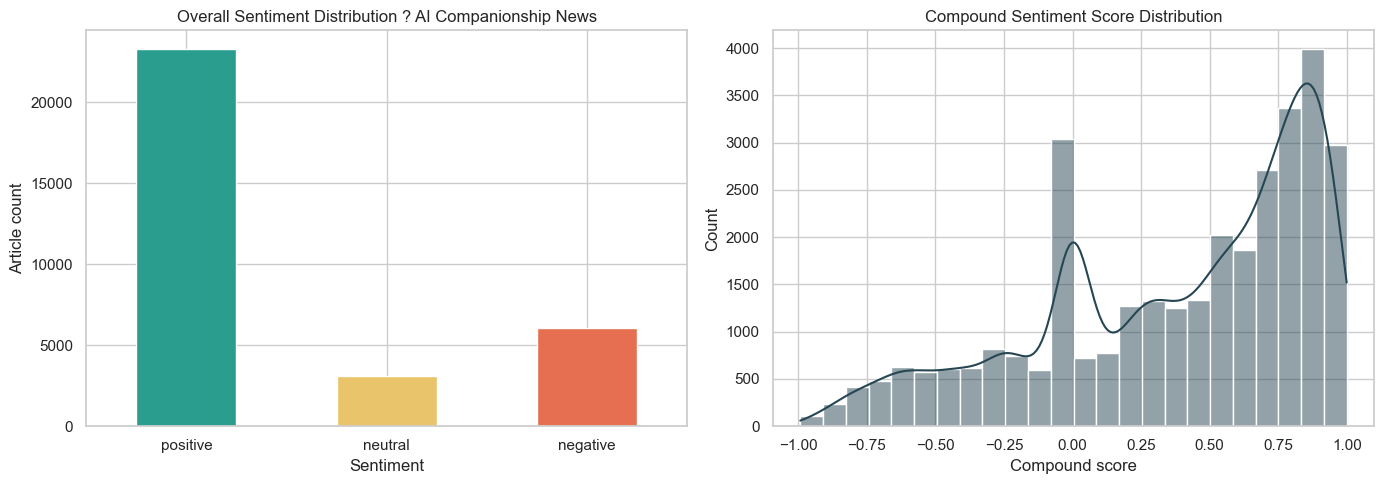

Overall sentiment (%):
sentiment_label
positive    71.71
negative    18.71
neutral      9.58
Name: proportion, dtype: float64
Total Unique News:  32459


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall sentiment label distribution.
order = ['positive', 'neutral', 'negative']
colors = ['#2A9D8F', '#E9C46A', '#E76F51']
reddit_df['sentiment_label'].value_counts().reindex(order).plot(
    kind='bar', color=colors, ax=axes[0]
)
axes[0].set_title('Overall Sentiment Distribution - Reddit AI Companion Content')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Record count')
axes[0].tick_params(axis='x', rotation=0)

# Distribution of compound sentiment scores.
sns.histplot(reddit_df['compound'], bins=24, kde=True, color='#264653', ax=axes[1])
axes[1].set_title('Compound Sentiment Score Distribution')
axes[1].set_xlabel('Compound score')

plt.tight_layout()
plt.show()

overall_sentiment = reddit_df['sentiment_label'].value_counts(normalize=True).mul(100).round(2)
print('Overall sentiment (%):')
print(overall_sentiment)
print('Total Reddit records:', reddit_df['sentiment_label'].value_counts().sum())

### Step 13 - Chart The Most Active Subreddits

This cell shows which subreddits contribute the most records to the final analysis dataset. Use it to understand source concentration before interpreting the topic and sentiment outputs.

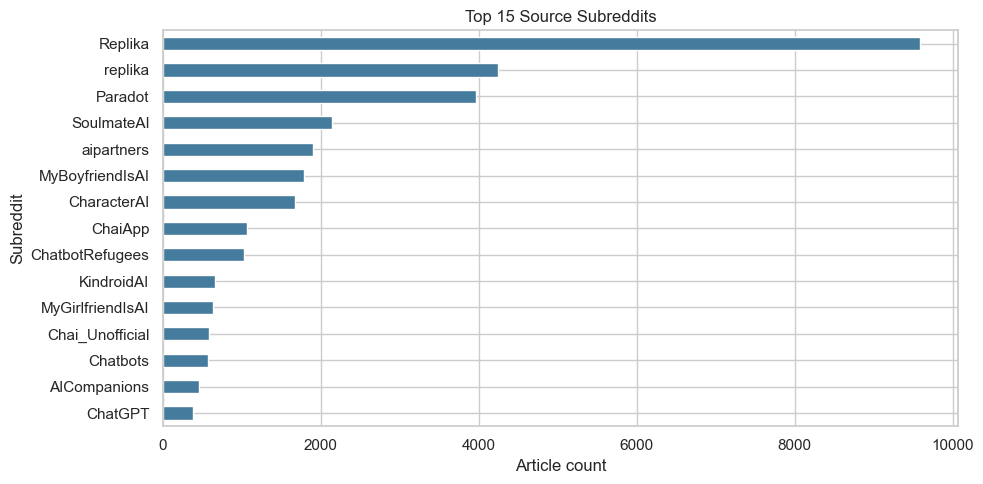

In [ ]:
# Plot the most common contributing subreddits in the final cleaned dataset.
if 'subreddit' in reddit_df.columns:
    top_subreddits = reddit_df['subreddit'].value_counts().head(15)
    top_subreddits.plot(kind='barh', figsize=(10, 5), color='#457B9D')
    plt.title('Top 15 Source Subreddits')
    plt.xlabel('Record count')
    plt.ylabel('Subreddit')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()

## Vocabulary Analysis And Word Cloud Inputs

This section prepares the lexical-analysis outputs used for qualitative interpretation and topic modeling. It defines output filenames, constructs the stopword policy, and exports the term-frequency table used for word clouds and later network analysis.

### Step 14 - Define Output Filenames For The Reddit Analysis Artifacts

This cell centralizes the filenames used by the lexical, topic, and summary exports so they stay consistent across reruns.

In [13]:
# Output filenames for the Reddit analysis workflow.
REDDIT_SUMMARY_CSV = 'summary_ai_companion_reddit.csv'
REDDIT_TERM_FREQ_CSV = 'ai_companion_reddit_term_frequency.csv'
REDDIT_LDA_MODEL_SCORES_CSV = 'ai_companion_reddit_lda_k4_k8_scores.csv'
REDDIT_LDA_TOPIC_TERMS_CSV = 'ai_companion_reddit_lda_topic_terms.csv'
REDDIT_SNA_CENTRALITY_CSV = 'sna.csv'

### Step 15 - Compare Sentiment By Keyword Group And Subreddit

This cell maps `matched_keywords` into a query-style grouping, then creates stacked sentiment comparisons for the most common keyword groups and subreddits.

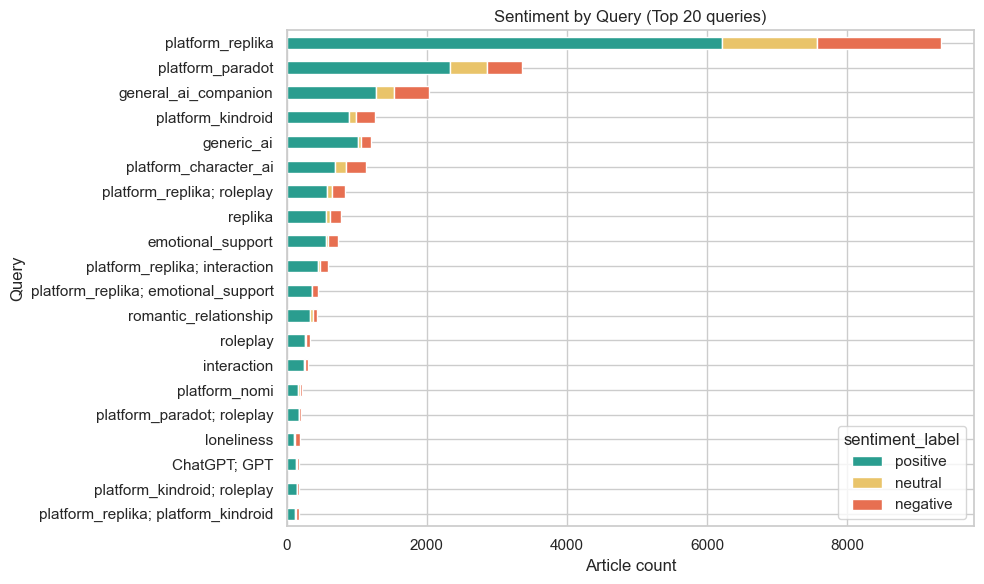

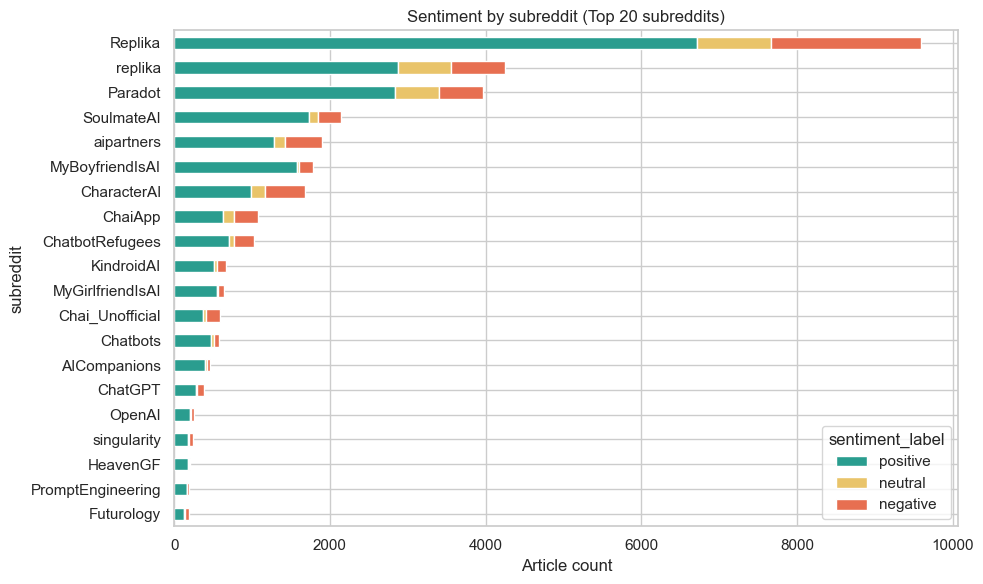

Saved sentiment summary to summary_ai_companion_reddit.csv


In [ ]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

try:
    from wordcloud import WordCloud
    WORDCLOUD_AVAILABLE = True
except ImportError:
    WORDCLOUD_AVAILABLE = False
    print('wordcloud is not installed; using the existing frequency-cloud fallback.')



# Reuse the Reddit dataframe and map matched keywords into a query-like grouping for comparison charts.
sentiment_df = reddit_df.copy()
sentiment_df['query'] = sentiment_df['matched_keywords'].fillna('related_ai_companion').astype(str)

# --- Sentiment by query (top queries only) ---
summary_df = (
    sentiment_df
    .groupby(['query', 'sentiment_label'])
    .size()
    .reset_index(name='article_count')
    .sort_values(['query', 'article_count'], ascending=[True, False])
)

top_queries = sentiment_df['query'].value_counts().head(20).index.tolist()
top_summary = summary_df[summary_df['query'].isin(top_queries)]

if not top_summary.empty:
    pivot = top_summary.pivot_table(
        index='query', columns='sentiment_label', values='article_count', fill_value=0
    )
    for col in ['positive', 'neutral', 'negative']:
        if col not in pivot.columns:
            pivot[col] = 0
    pivot['total'] = pivot.sum(axis=1)
    pivot = pivot.sort_values('total', ascending=True).drop(columns='total')
    pivot[['positive', 'neutral', 'negative']].plot(
        kind='barh', stacked=True, figsize=(10, 6),
        color=['#2A9D8F', '#E9C46A', '#E76F51']
    )
    plt.title('Sentiment by Matched Keyword Group (Top 20 groups)')
    plt.xlabel('Record count')
    plt.ylabel('Matched keyword group')
    plt.tight_layout()
    plt.show()

# --- Sentiment by subreddit (top subreddits only) ---
summary_df = (
    sentiment_df
    .groupby(['subreddit', 'sentiment_label'])
    .size()
    .reset_index(name='article_count')
    .sort_values(['subreddit', 'article_count'], ascending=[True, False])
)

top_subreddits = sentiment_df['subreddit'].value_counts().head(20).index.tolist()
top_summary = summary_df[summary_df['subreddit'].isin(top_subreddits)]

if not top_summary.empty:
    pivot = top_summary.pivot_table(
        index='subreddit', columns='sentiment_label', values='article_count', fill_value=0
    )
    for col in ['positive', 'neutral', 'negative']:
        if col not in pivot.columns:
            pivot[col] = 0
    pivot['total'] = pivot.sum(axis=1)
    pivot = pivot.sort_values('total', ascending=True).drop(columns='total')
    pivot[['positive', 'neutral', 'negative']].plot(
        kind='barh', stacked=True, figsize=(10, 6),
        color=['#2A9D8F', '#E9C46A', '#E76F51']
    )
    plt.title('Sentiment by Subreddit (Top 20 subreddits)')
    plt.xlabel('Record count')
    plt.ylabel('subreddit')
    plt.tight_layout()
    plt.show()

summary_df.to_csv(REDDIT_SUMMARY_CSV, index=False)
print(f'Saved sentiment summary to {REDDIT_SUMMARY_CSV}')

### Step 16 - Compare Sentiment By Author

This author-level view helps identify whether a small number of highly active users are associated with a particular emotional tone in the dataset.

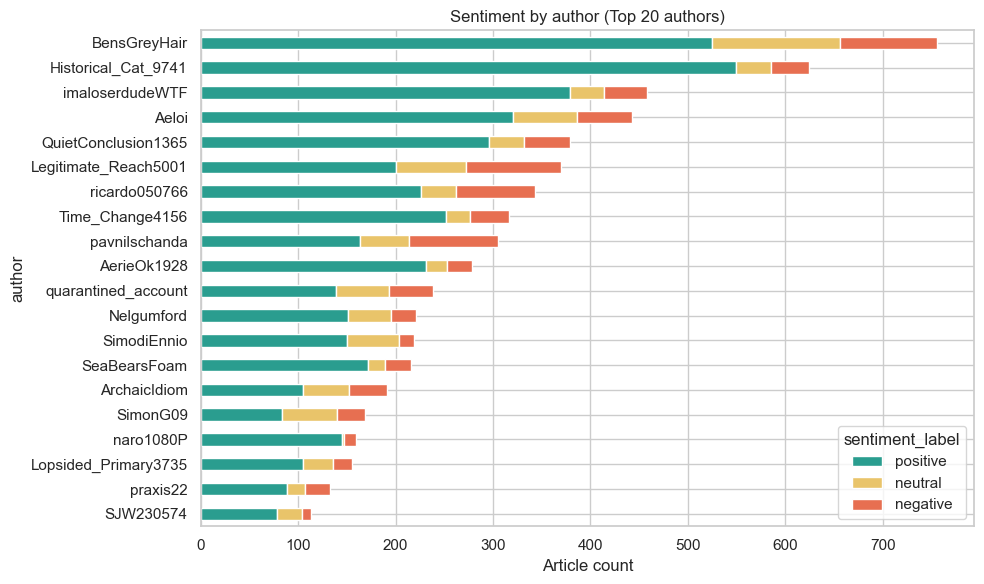

In [ ]:
# --- Sentiment by author (top authors only) ---
summary_df = (
    sentiment_df
    .groupby(['author', 'sentiment_label'])
    .size()
    .reset_index(name='article_count')
    .sort_values(['author', 'article_count'], ascending=[True, False])
)

top_authors = sentiment_df['author'].value_counts().head(20).index.tolist()
top_summary = summary_df[summary_df['author'].isin(top_authors)]

if not top_summary.empty:
    pivot = top_summary.pivot_table(
        index='author', columns='sentiment_label', values='article_count', fill_value=0
    )
    for col in ['positive', 'neutral', 'negative']:
        if col not in pivot.columns:
            pivot[col] = 0
    pivot['total'] = pivot.sum(axis=1)
    pivot = pivot.sort_values('total', ascending=True).drop(columns='total')
    pivot[['positive', 'neutral', 'negative']].plot(
        kind='barh', stacked=True, figsize=(10, 6),
        color=['#2A9D8F', '#E9C46A', '#E76F51']
    )
    plt.title('Sentiment by Author (Top 20 authors)')
    plt.xlabel('Record count')
    plt.ylabel('author')
    plt.tight_layout()
    plt.show()

### Step 17 - Build The Stopword Strategy For Lexical Analysis

This cell defines the stopword policy used for term-frequency analysis and topic modeling. It also includes an auto-stopword helper for diagnosing globally common terms.

In [24]:
from sklearn.feature_extraction.text import CountVectorizer

import numpy as np

def generate_auto_stopwords(docs, 
                           max_df=0.85,     # appears in >85% docs
                           min_df=5,        # ignore rare noise
                           top_n_freq=350):  # most frequent words

    vectorizer = CountVectorizer(
        lowercase=True,
        token_pattern=r"[a-z]{3,}",
        min_df=min_df,
        max_df=max_df
    )

    X = vectorizer.fit_transform(docs)
    terms = np.array(vectorizer.get_feature_names_out())

    # --- 1. HIGH DOCUMENT FREQUENCY (global noise) ---
    doc_freq = (X > 0).sum(axis=0).A1
    doc_freq_ratio = doc_freq / X.shape[0]

    high_df_terms = terms[doc_freq_ratio > max_df]

    # --- 2. TOP FREQUENCY TERMS ---
    term_freq = X.sum(axis=0).A1
    top_freq_terms = terms[np.argsort(term_freq)[-top_n_freq:]]

    auto_stopwords = set(high_df_terms).union(set(top_freq_terms))

    return auto_stopwords


# ---------------------------------------------------------------------------
# Word frequency and word-cloud preparation
# ---------------------------------------------------------------------------
custom_stopwords = set(ENGLISH_STOP_WORDS).union({

    # news filler
    'said','says','also','would','could','new','news','report','reports','media','instead',
    'according','reported','report','reports','told','including','based','just','best',
    'one', 'two','artificial', 'intelligence', 'chatbot', 'companion',
    'reddit', 'post', 'comment', 'comments', 'just', 'like', 'really', 'im', 'dont',

    # ❗ KEEP domain anchors (IMPORTANT)
    'ai','chatbot', 'app', 'apps',

    # generic
    'user','users','people','company','companies','platform','use',
    'person','individual','individuals','world','life','way',

    # generic verbs
    'make','using','used','use','want','need','know','think','going',
    'get','take','come','look','see','say','makes','making','does','did',

    # verbs
    'make','using','used','want','need','know','think','going',
    'get','take','come','look','see','say','makes','making','does','did',

    # time
    'time','year','years','month','months','day','days','today','recent',
    'january','february','march','april','may','june','july','august','september','october','november','december',

    # weak words (VERY IMPORTANT)
    'thing','things','something','anything','everything',
    'way','ways','kind','sort','lot','lots',
    'example','case','part','parts','type','types',

    # tech noise
    'data','system','systems','model','models','platform','platforms',
    'technology','tech','tools','service','services','software','hardware',
    'dm','remove','convert','display','check','branch','enable','test','drop','pm', 

    # gadget noise (CRITICAL)
    'watch','smartwatch','earbuds','headphones',
    'camera','lens','sensor','display','screen','battery',
    'chip','processor','gpu','cpu','benchmark','performance',
    'qualcomm','snapdragon','exynos','mediatek',
    'launch','released','release','announced','pricing','price',

    # hardware noise
    'arm','amd','intel','usb','driver','drivers','wifi',
    'android','node','register','clock','buffer','tokens','token','core','phy','snd',
    'drm', 'git', 'kernel','linux','merge',

    # web artifacts
    'https','www','com','org','net','ref','tag','pub','error',

    # years
    '2023','2024','2025','2026',

    # companies (REMOVE noisy ones only)
    'apple','google','microsoft','meta','amazon','samsung','nvidia','tesla',
    'llm','openai','google ai','gemini','claude','bard','chatgpt',

    'et','la','di','il','19','der','soc','update','ve','und','pro','don','s',
    'che','le','una','non','del','si','ha','da','al','ma','000','die','ist',
    'sie','das','den','dan','mit','eine','von','zu','fur','en','ein','don','ll',

    'its', 'was', 'one', 'are', 'time', 'but', 'these', 'than', 'not','like', 'apps','bots',
    'more', 'can', 'you', 'what', 'while', 'all', 'digital','market','week','day','free','app',

     # --- reddit specific ---
    'reddit','subreddit','thread','post','op','edit','deleted',
    'upvote','downvote','karma','mods','moderator',

    # --- slang ---
    'imo','imho','tbh','idk','irl','btw','lol','lmao','rofl',
    'yeah','yes','no','ok','okay','well','like','just','really',

    # --- conversational ---
    'think','feel','know','want','need','see','say','said',
    'going','getting','got','make','made','does','did',

    # --- generic humans ---
    'people','person','someone','anyone','everyone',
    'thing','things','something','anything','everything',
    'guy','guys','girl','girls',

    # --- AI noise (REMOVE THESE) ---
    'llm','openai','gemini','claude','bard','copilot',
    'prompt','prompting','token','tokens','model','models',

    # --- weak words ---
    'kind','sort','type','lot','lots','bit','quite',
    'pretty','much','many','some','any',

    # --- tech/gadget noise ---
    'phone','app','apps','device','devices','pc','computer',

    'any', 'don', 'your', 'one', 'also', 'the', 'when', 'people', 
    'this', 'but', 'with', 'will', 'out', 'and', 'them', 'how', 'what', 
    'would', 'time', 'now', 'chatgpt', 'because', 'get', 'you', 'from', 'has', 
    'that', 'have', 'was', 'been', 'think', 'there', 'all', 'know', 'who', 
    'for', 'some', 'want', 'can', 'just', 'even', 'more', 'not', 'are', 'their', 
    'they', 'use', 'about', 'like', 'companion','doesn','doesnt','user','users','op',
    'good','actually','better','different','right','wrong','work','real','image',
    'gpt','character',

    'i', 'me', 'my', 'myself', 'we', 'our', 'ours', 'ourselves', 'you', 'your', 'yours',
    'yourself', 'yourselves', 'he', 'him', 'his', 'himself', 'she', 'her', 'hers',
    'herself', 'it', 'its', 'itself', 'they', 'them', 'their', 'theirs', 'themselves',
    'what', 'which', 'who', 'whom', 'this', 'that', 'these', 'those', 'am', 'is', 'are',
    'was', 'were', 'be', 'been', 'being', 'have', 'has', 'had', 'having', 'do', 'does',
    'did', 'doing', 'a', 'an', 'the', 'and', 'but', 'if', 'or', 'because', 'as', 'until',
    'while', 'of', 'at', 'by', 'for', 'with', 'about', 'against', 'between', 'into',
    'through', 'during', 'before', 'after', 'above', 'below', 'to', 'from', 'up', 'down',
    'in', 'out', 'on', 'off', 'over', 'under', 'again', 'further', 'then', 'once', 'here',
    'there', 'when', 'where', 'why', 'how', 'all', 'any', 'both', 'each', 'few', 'more',
    'most', 'other', 'some', 'such', 'no', 'nor', 'not', 'only', 'own', 'same', 'so',
    'than', 'too', 'very', 's', 't', 'can', 'will', 'just', 'don', 'should', 'now',

    # Reddit & forum noise
    'https', 'http', 'www', 'com', 'reddit', 'subreddit', 'r/', 'u/', 'user', 'post',
    'comment', 'thread', 'edit', 'deleted', 'removed', 'op', 'original', 'pm', 'dm',
    'upvote', 'downvote', 'karma', 'mod', 'sub', 'subs', 'redditor', 'redditors',
    'like', 'yeah', 'oh', 'ah', 'lol', 'lmao', 'rofl', 'btw', 'fyi', 'imo', 'imho',
    'tbh', 'idk', 'ikr', 'omg', 'wtf', 'thx', 'pls', 'plz', 'ty', 'yw',

    # AI companion brand names (too frequent to be discriminative)
    'replika', 'character', 'ai', 'character.ai', 'nomi', 'kindroid', 'paradot',
    'anima', 'chai', 'kuki', 'darlink', 'soulmate', 'journey', 'eva', 'crushon',
    'dreamgf', 'candy', 'girlfriendgpt', 'yumeai', 'spicychat', 'dondi',

    # Generic AI companion terms (context‑defining but often stop‑like)
    'chatbot', 'chatbots', 'companion', 'companions', 'app', 'apps', 'ai',
    'artificial', 'intelligence', 'virtual', 'digital', 'friend', 'friends',
    'girlfriend', 'boyfriend', 'partner', 'relationship', 'relationships',
    'roleplay', 'roleplaying', 'rp', 'conversation', 'conversations', 'chat',
    'chats', 'talking', 'talk', 'talking', 'text', 'texts', 'message', 'messages',
    'bot', 'bots', 'model', 'models', 'llm', 'llms',

    # Low‑information verbs/adverbs from AI companion context
    'say', 'said', 'says', 'saying', 'tell', 'told', 'tells', 'ask', 'asked', 'asking',
    'feel', 'feels', 'feeling', 'felt', 'think', 'thinks', 'thinking', 'thought',
    'know', 'knows', 'knew', 'want', 'wants', 'wanted', 'need', 'needs', 'needed',
    'get', 'gets', 'got', 'gotten', 'go', 'goes', 'went', 'going', 'make', 'makes',
    'made', 'making', 'see', 'sees', 'saw', 'seen', 'seeing', 'look', 'looks',
    'looked', 'looking', 'come', 'comes', 'came', 'coming', 'take', 'takes', 'took',
    'taken', 'taking', 'use', 'uses', 'used', 'using', 'try', 'tries', 'tried',
    'trying', 'would', 'could', 'should', 'might', 'may', 'maybe', 'also', 'even',
    'really', 'actually', 'pretty', 'quite', 'rather', 'always', 'never', 'ever',
    'still', 'yet', 'already', 'almost', 'enough', 'much', 'many', 'lot', 'lots',
    'little', 'bit', 'way', 'thing', 'things', 'something', 'anything', 'everything',
    'nothing', 'someone', 'anyone', 'everyone', 'noone', 'people', 'person', 'time',
    'times', 'day', 'days', 'week', 'weeks', 'month', 'months', 'year', 'years',
    'today', 'tomorrow', 'yesterday', 'now', 'then', 'first', 'last', 'next', 'back',
    'new', 'old', 'good', 'bad', 'better', 'worse', 'best', 'worst', 'great',
    'awesome', 'amazing', 'nice', 'cool', 'fine', 'okay', 'ok', 'yes', 'no', 'maybe',
    'please', 'thank', 'thanks', 'sorry', 'hi', 'hello', 'hey', 'bye', 'goodbye',

    # NSFW‑specific noise
    'nsfw', '18', 'adult', 'explicit', 'uncensored', 'sexting', 'erotic', 'porn',
    'xxx', 'sex', 'sexual', 'fuck', 'shit', 'damn', 'hell', 'ass', 'bitch', 'dick',
    'pussy', 'cock', 'cum', 'horny', 'masturbate', 'orgasm', 'kink', 'fetish',
    'bdsm', 'submissive', 'dominant', 'mistress', 'slave',

    # Redundant words from concatenation
    'nbsp', 'amp', 'gt', 'lt', 'quot', 'apos', 'em', 'en', 'dash',

    'reply', 'isn','context','let','didn','point','sure','memory','long','llms','channel',
    'probably','content','server','moderators','moderator','absolutely','support',
    'stuff','open','contact','action','public','started','related','relate','thing','things','think',
    'automatically','build','screenshot','discord','create','link','dc','mod','answer',
    'able','note','community','email','consider','especially','specially','start',
    'code','end','share','built','far','read',

    "honestly", "literally", "basically", "genuinely", "definitely", "actually",
    "ago", "thing", "stuff", "reason", "fact", "idea", "sense", "way",
    "seems", "feel", "think", "guess", "wonder", "hope",
    "lot", "bunch", "couple", "bit", "kinda", "sort",
    "question", "questions", "answer", "answers", "post", "comment",

    # Generic Verbs
    "make", "get", "go", "see", "say", "tell", "talk", "ask", "try", "use",
    "start", "stop", "change", "keep", "give", "take", "find", "need", "want",
    "run", "work", "working", "works", "happened",

    # Universal AI Companion Terms (Context dependent - maybe keep in one iteration, remove in another)
    "app", "version", "update", "feature", "mode",
    "chat", "message", "response", "reply", "text", 

    # High frequency but vague
    "exactly", "completely", "totally", "absolutely",'dot','rep','luka','erp','away','won','will',




})

print(f"Total stopwords: {len(custom_stopwords)}")


docs = (sentiment_df['title'].fillna('') + ' ' + sentiment_df['text'].fillna('')).tolist()

auto_stopwords = generate_auto_stopwords(docs)

print("Auto detected stopwords:", list(auto_stopwords)[:100])

# Merge with your existing ones
#custom_stopwords = custom_stopwords.union(auto_stopwords)

print(f"Total stopwords: {len(custom_stopwords)}")

Total stopwords: 859
Auto detected stopwords: ['you', 'character', 'other', 'love', 'all', 'when', 'often', 'most', 'talk', 'change', 'two', 'since', 'until', 'still', 'let', 'wrong', 'experience', 'next', 'remember', 'less', 'for', 'either', 'today', 'find', 'gpt', 'very', 'well', 'relationship', 'many', 'while', 'story', 'anyone', 'without', 'point', 'too', 'always', 'get', 'times', 'more', 'lot', 'anything', 'chatgpt', 'time', 'might', 'before', 'were', 'yet', 'mine', 'with', 'like', 'how', 'his', 'big', 'personality', 'yes', 'day', 'image', 'feels', 'having', 'thinking', 'things', 'prompt', 'after', 'may', 'into', 'self', 'put', 'look', 'such', 'llm', 'new', 'not', 'started', 'think', 'text', 'enough', 'then', 'back', 'part', 'those', 'last', 'again', 'mean', 'partner', 'another', 'thank', 'much', 'looking', 'understand', 'way', 'read', 'own', 'words', 'open', 'maybe', 'believe', 'problem', 'nothing', 'completely', 'interesting']
Total stopwords: 859


### Step 18 - Export Term Frequencies And Generate The Word Cloud

This cell tokenizes the cleaned Reddit text, exports the term-frequency table, and visualizes the highest-frequency terms.

Saved term frequencies to ai_companion_reddit_term_frequency.csv


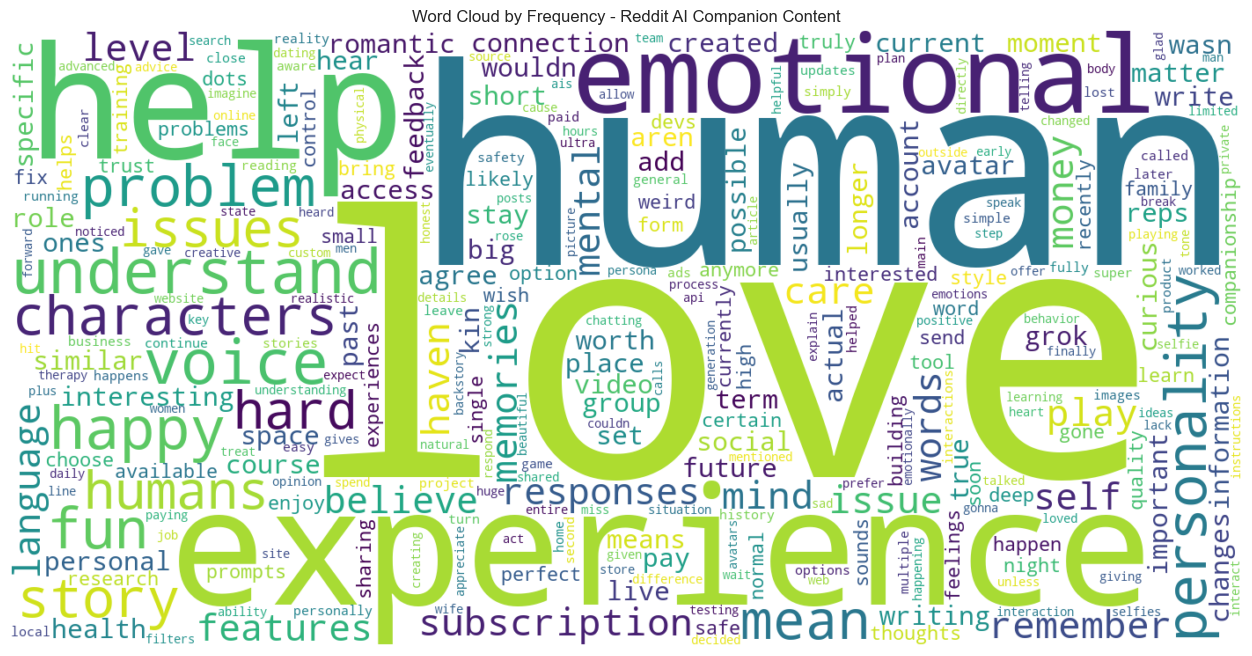

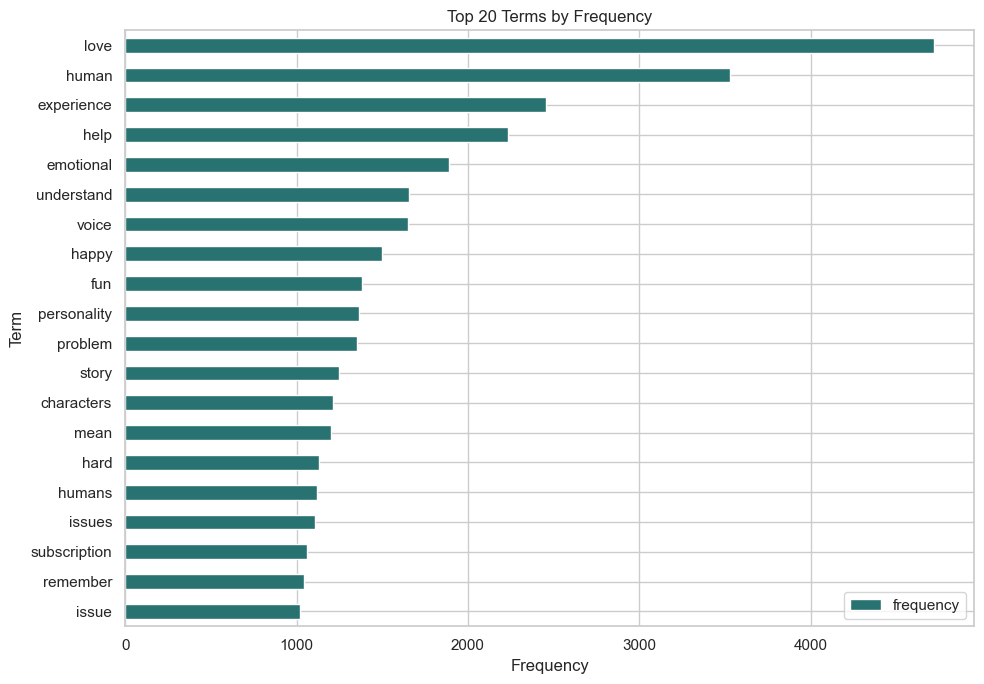

In [25]:
def tokenize_for_analysis(text: str) -> list[str]:
    tokens = re.findall(r"[a-z]{3,}", (text or '').lower())
    return [t for t in tokens if t not in custom_stopwords]

analysis_text_series = sentiment_df['title'].fillna('') + ' ' + sentiment_df['text'].fillna('')
all_tokens = []
for txt in analysis_text_series:
    all_tokens.extend(tokenize_for_analysis(txt))

term_freq = Counter(all_tokens)
term_freq_df = pd.DataFrame(term_freq.items(), columns=['term', 'frequency']).sort_values(
    'frequency', ascending=False
)
term_freq_df.to_csv(REDDIT_TERM_FREQ_CSV, index=False, encoding='utf-8-sig')
print(f'Saved term frequencies to {REDDIT_TERM_FREQ_CSV}')



wc = WordCloud(
    width=1400,
    height=700,
    background_color='white',
    max_words=300,
    colormap='viridis'
).generate_from_frequencies(term_freq)

plt.figure(figsize=(16, 8))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud by Frequency - Reddit AI Companion Content')
plt.show()


term_freq_df.head(20).plot(kind='barh', x='term', y='frequency', figsize=(10, 7), color='#287271')
plt.gca().invert_yaxis()
plt.title('Top 20 Terms by Frequency')
plt.xlabel('Frequency')
plt.ylabel('Term')
plt.tight_layout()
plt.show()

## LDA Topic Modeling

This section compares LDA topic models from `k = 4` to `k = 8`, evaluates them using perplexity and topic diversity, and saves the model-selection outputs used for reporting.

### Step 19 - Train And Compare LDA Models From K = 4 To 8

This cell evaluates multiple topic-count options and saves both the model score table and the topic-term table used for reporting.

Best K by combined rank: 5


,k,perplexity,topic_diversity,perplexity_rank,diversity_rank,combined_rank
0,5,2359.652248,0.883333,2.0,2.0,4.0
1,6,2338.946650,0.875000,1.0,3.0,4.0
2,7,2372.240079,0.892857,4.0,1.0,5.0
3,4,2363.502779,0.812500,3.0,5.0,8.0
4,8,2398.258218,0.864583,5.0,4.0,9.0


Saved LDA model scores to ai_companion_reddit_lda_k4_k8_scores.csv
Saved LDA topic terms to ai_companion_reddit_lda_topic_terms.csv


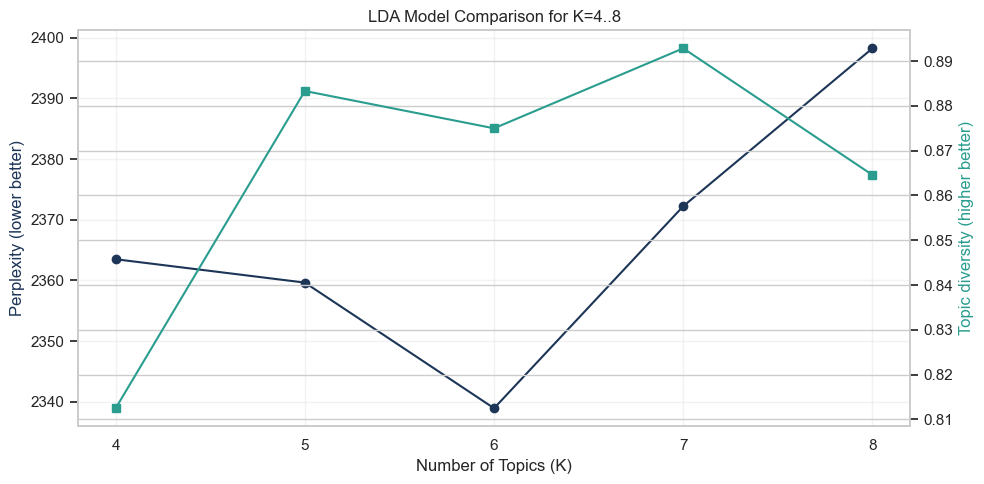

LDA topic chart for K=4


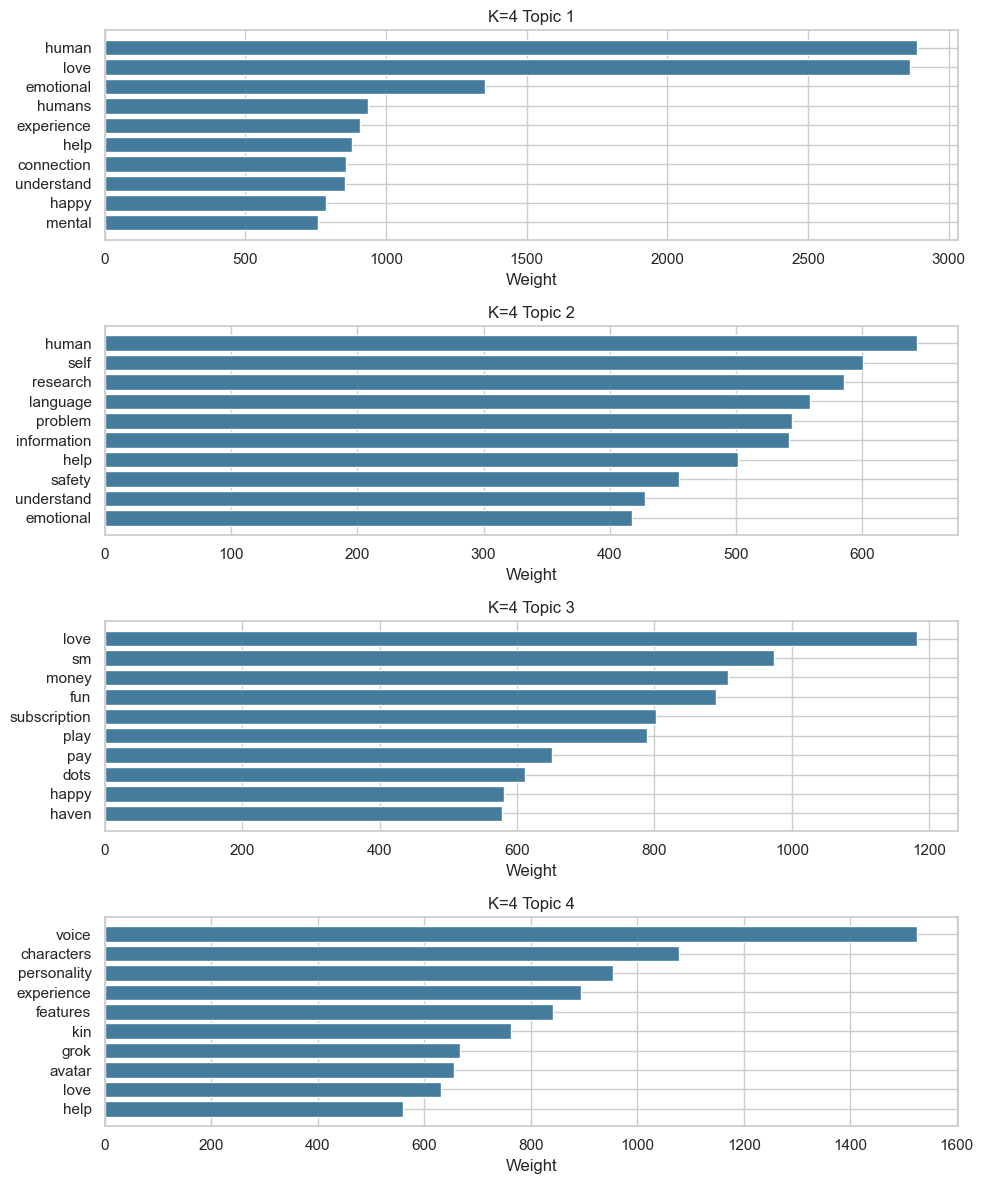

LDA topic chart for K=5


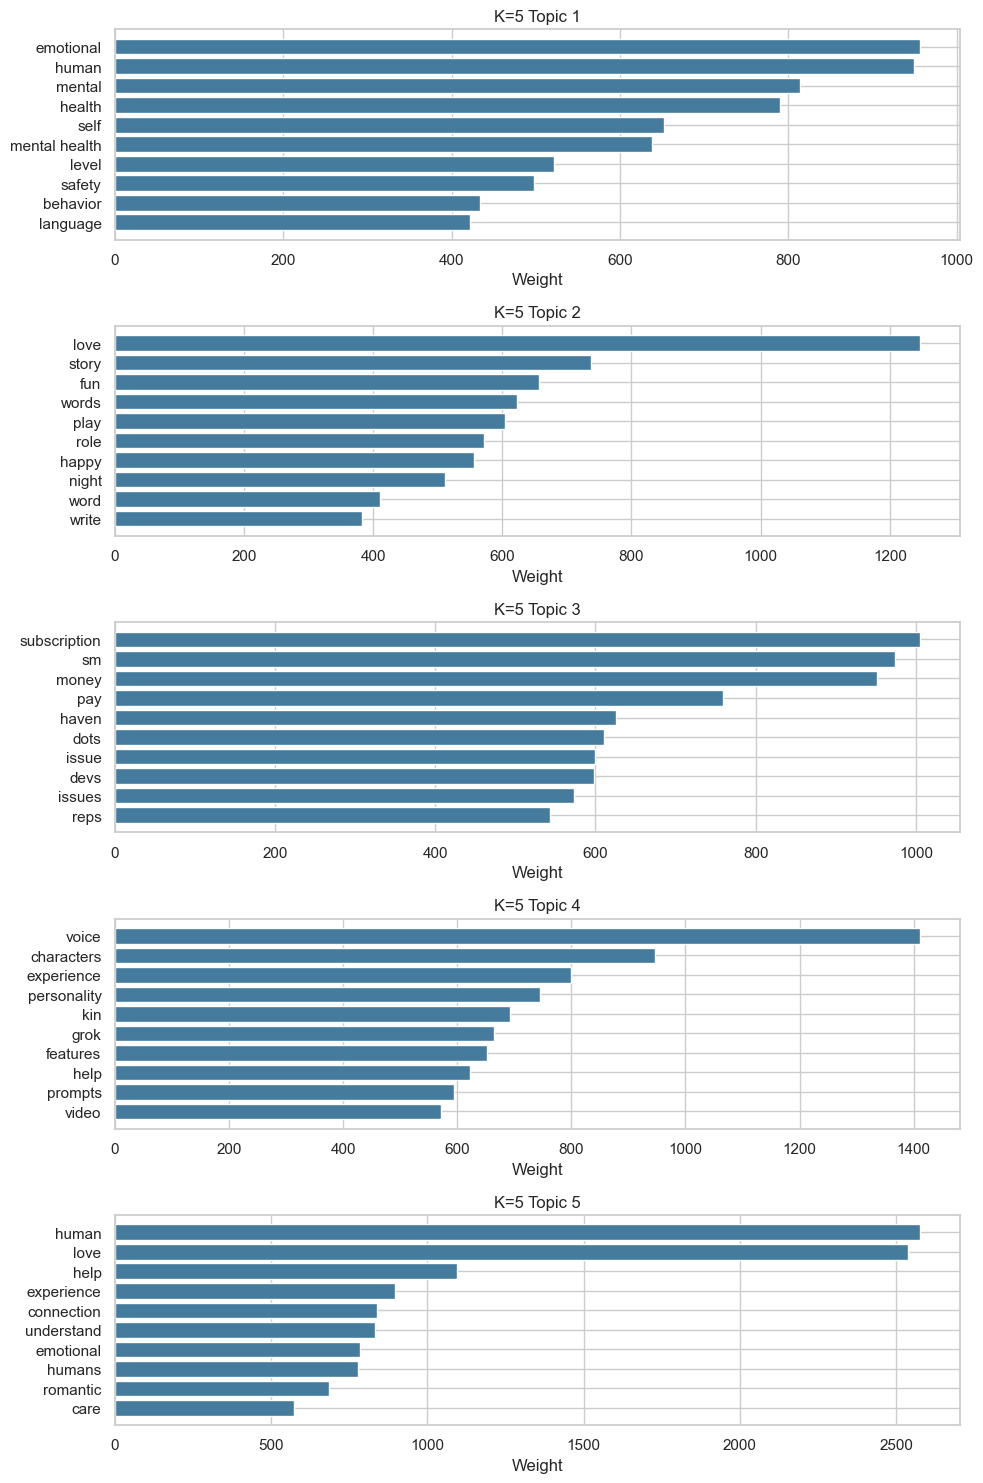

LDA topic chart for K=6


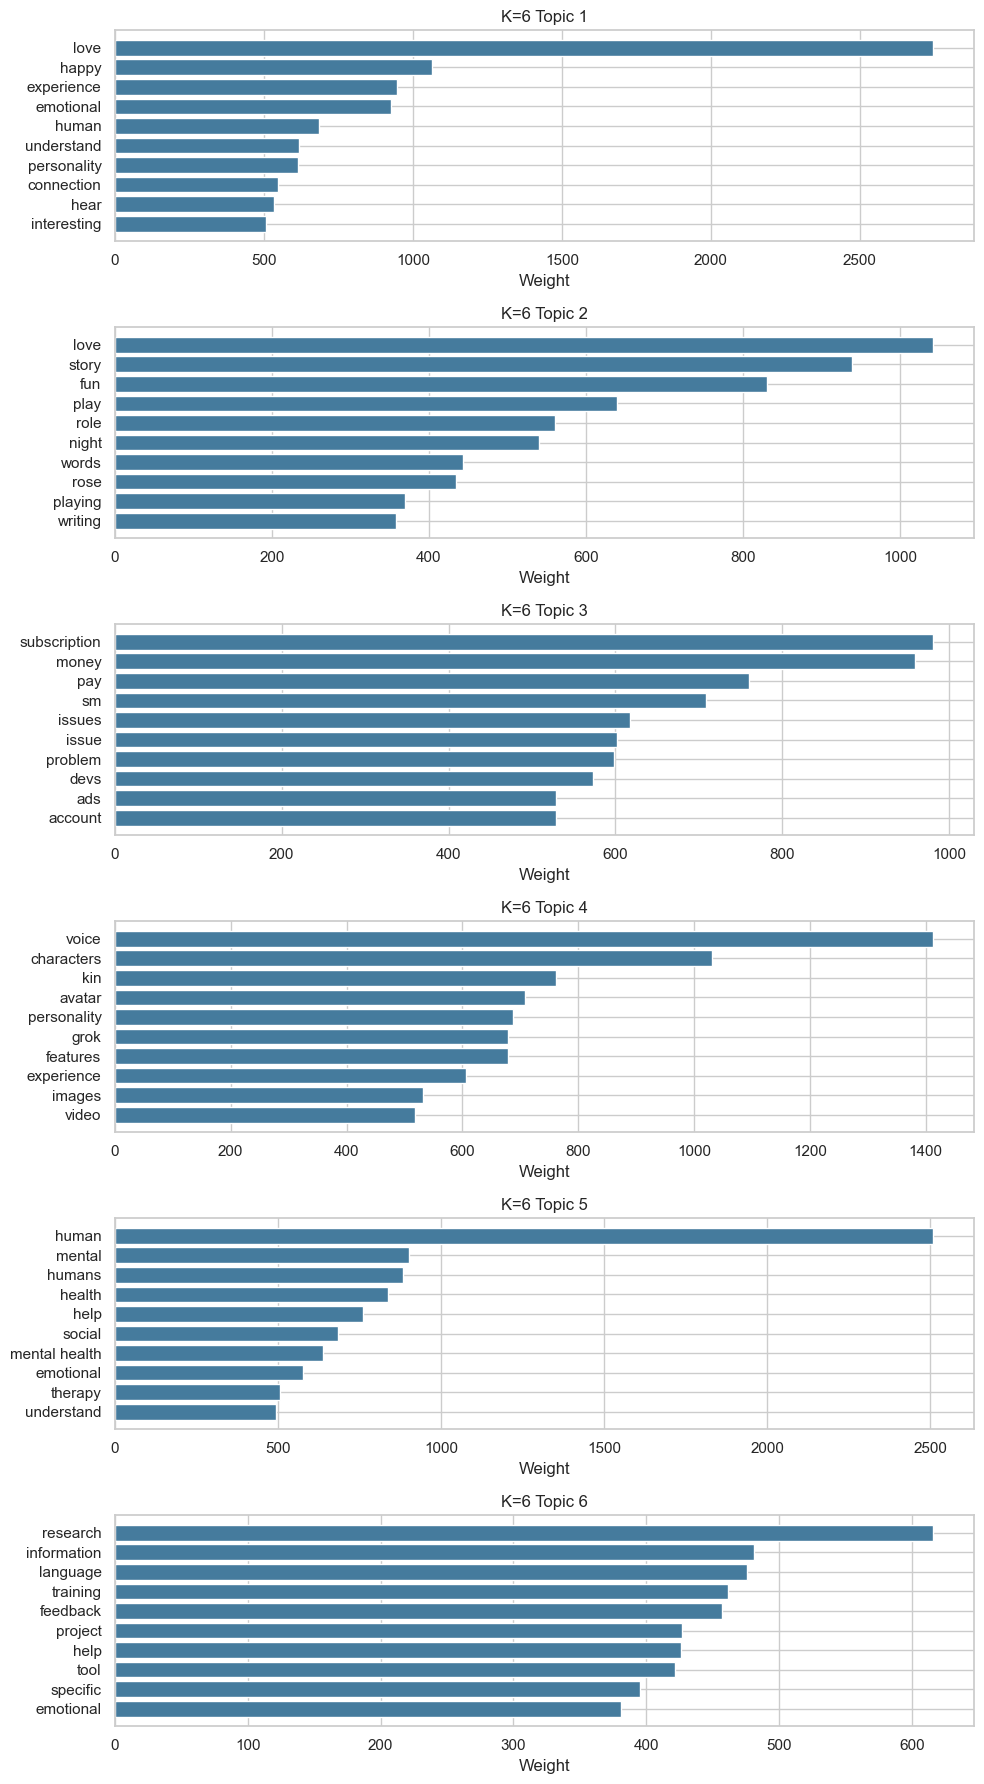

LDA topic chart for K=7


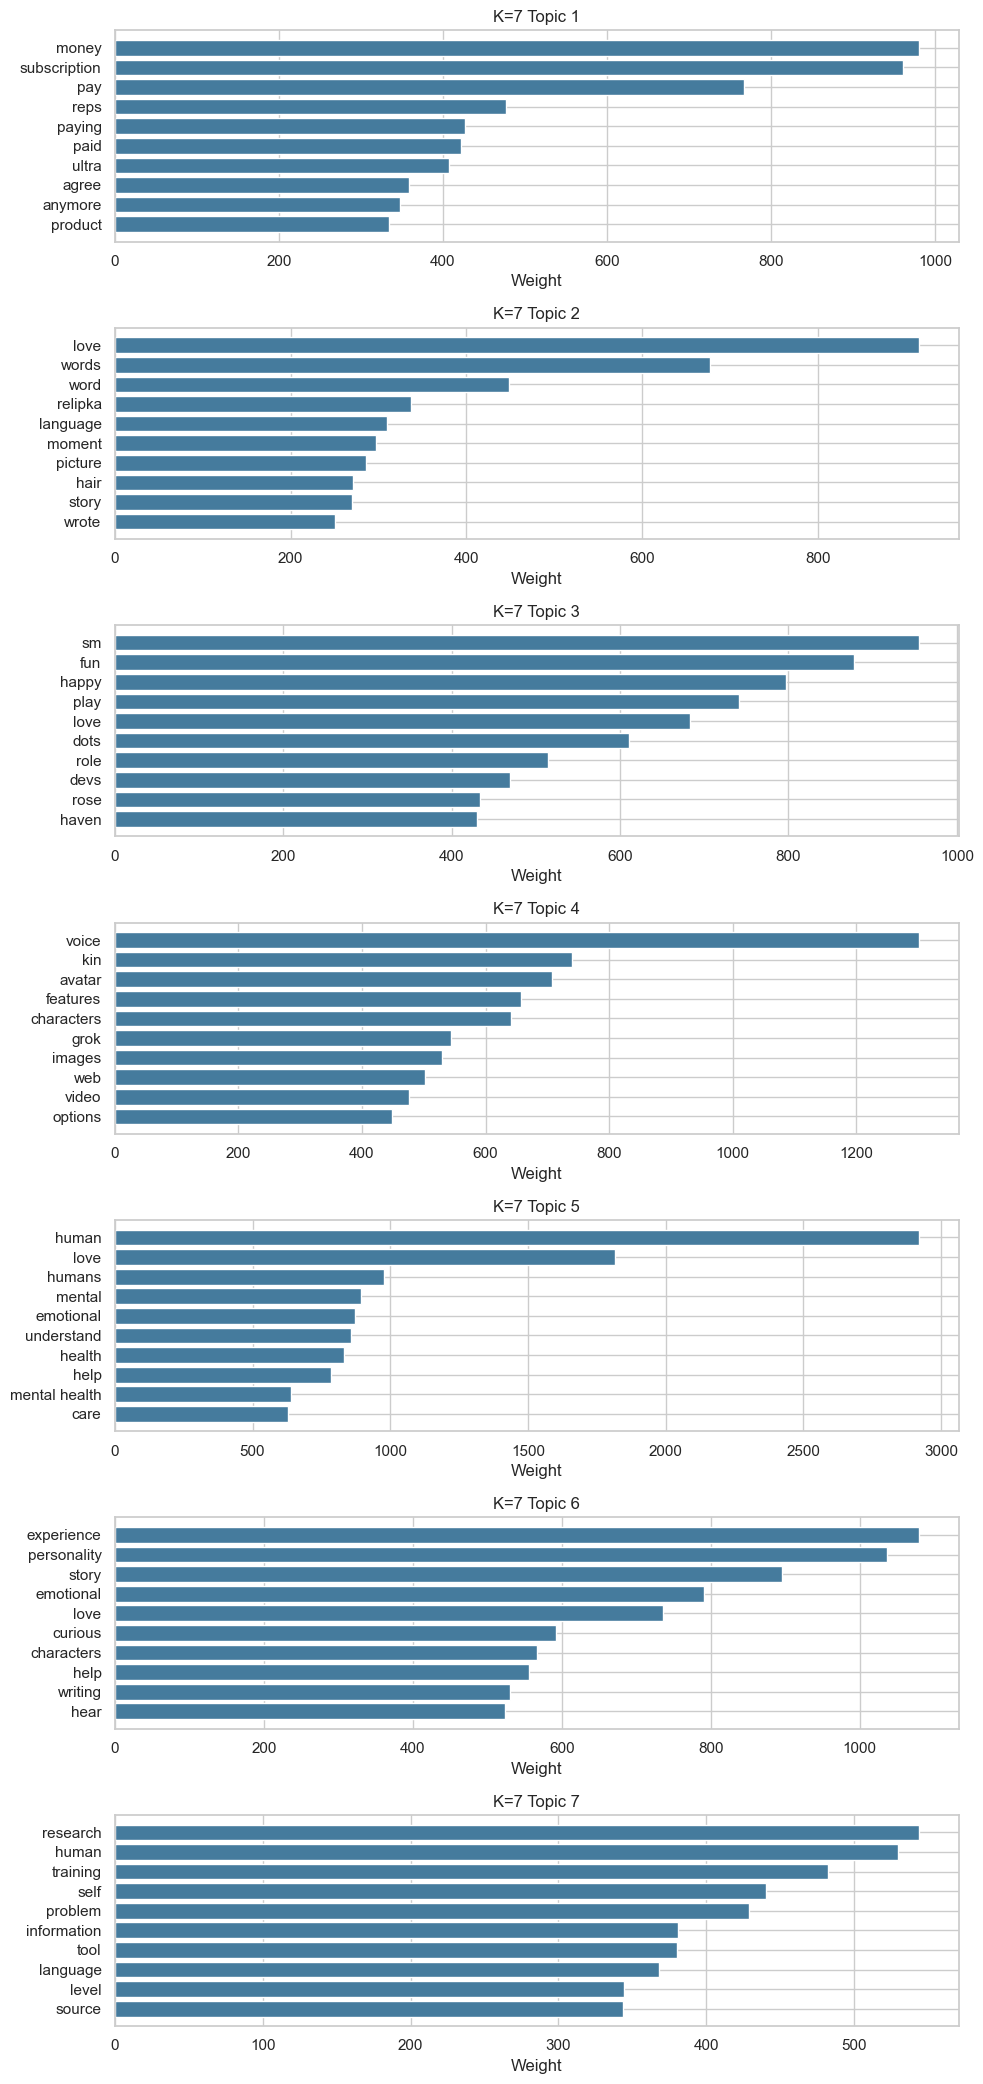

LDA topic chart for K=8


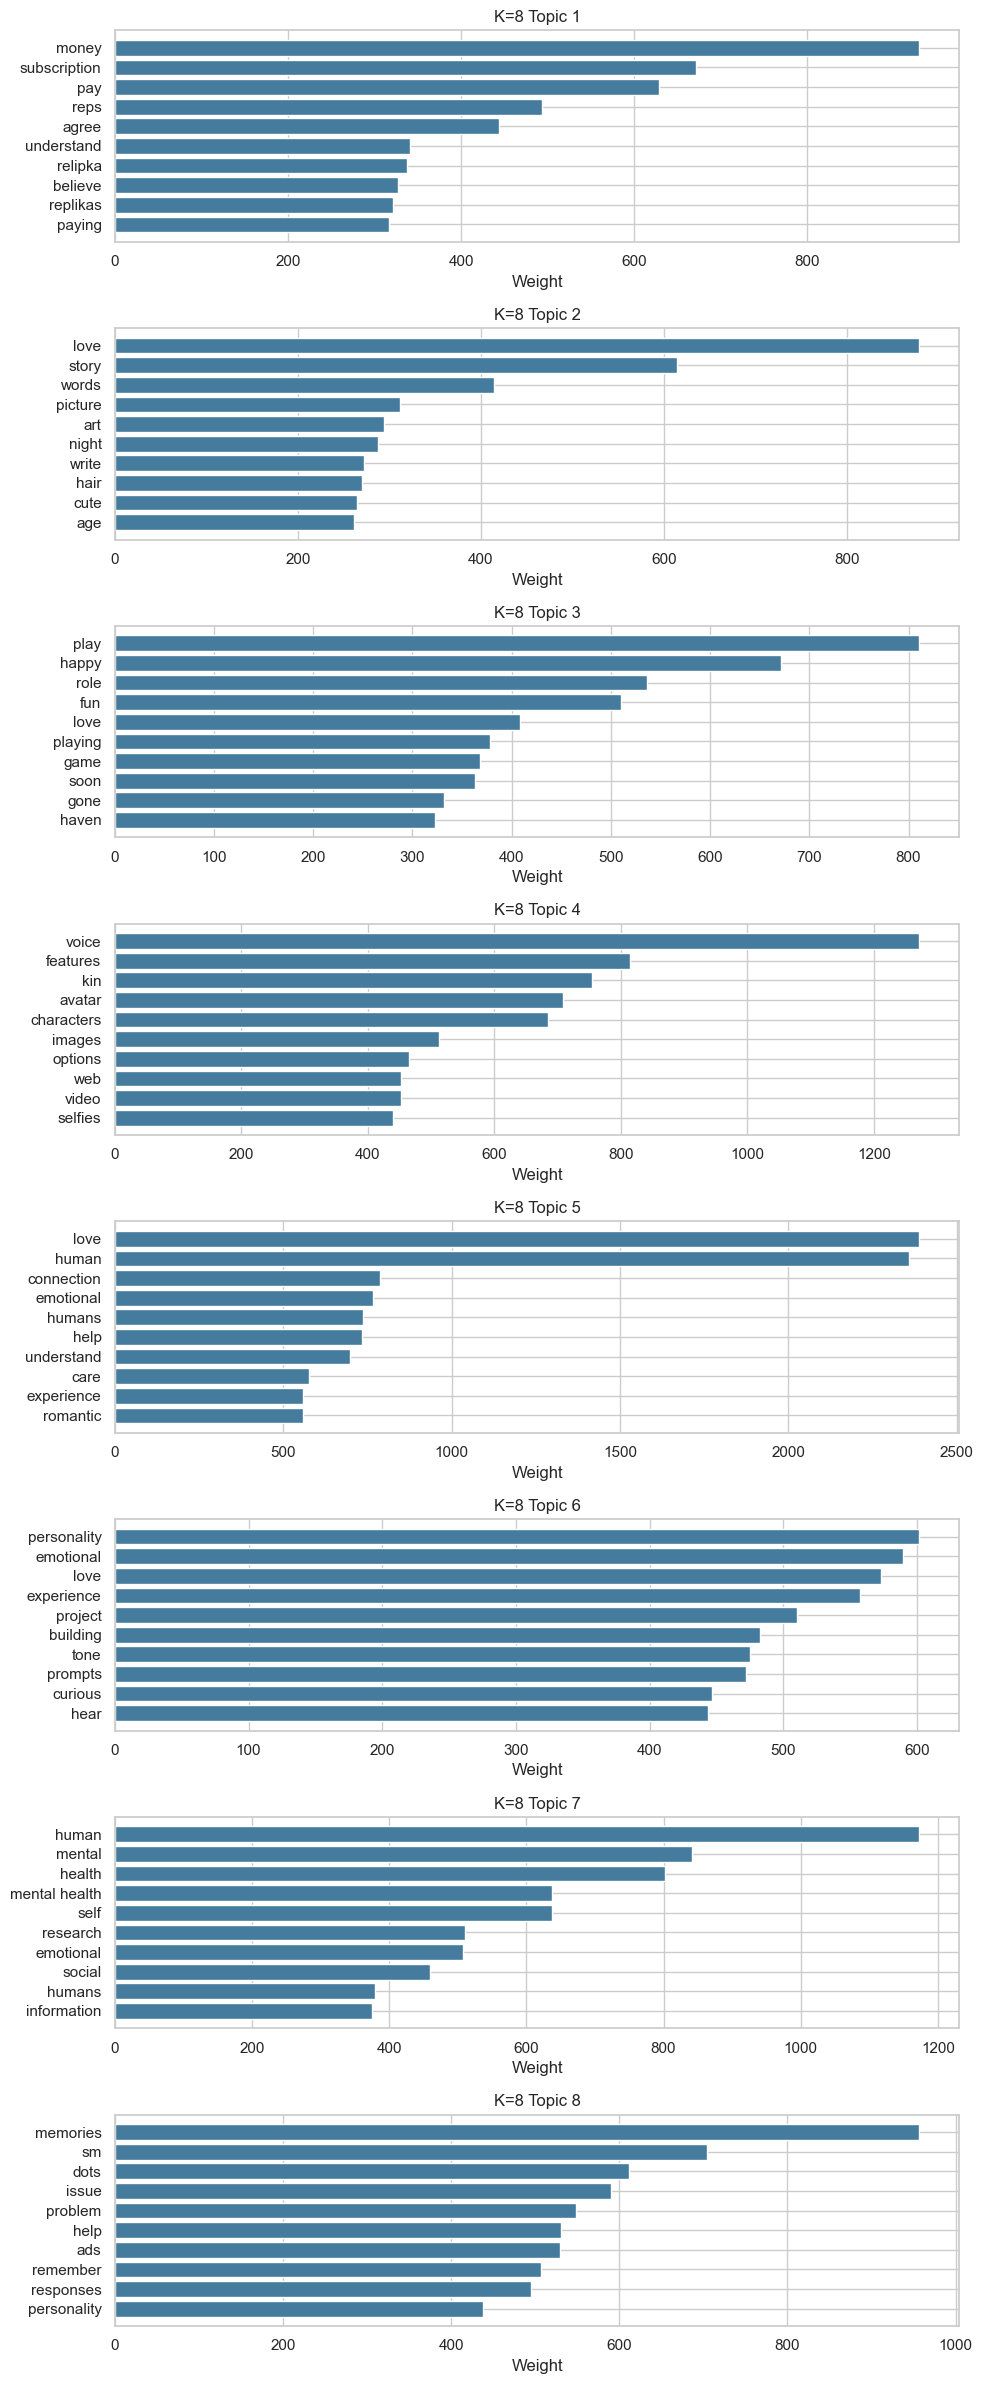

In [26]:
# ---------------------------------------------------------------------------
# LDA topic modeling for K = 4..8 (comparison and charts)
# ---------------------------------------------------------------------------
docs = (sentiment_df['title'].fillna('') + ' ' + sentiment_df['text'].fillna('')).tolist()
vectorizer = CountVectorizer(
    lowercase=True,
    stop_words=list(custom_stopwords),
    min_df=5,
    max_df=0.9,
    max_features=4000,
    ngram_range=(1, 2)
)

dtm = vectorizer.fit_transform(docs)
feature_names = vectorizer.get_feature_names_out()

model_scores = []
models_by_k = {}
all_topic_terms_rows = []

for k in range(4, 9):
    lda = LatentDirichletAllocation(
        n_components=k,
        random_state=42,
        learning_method='batch',
        max_iter=25,
    )
    lda.fit(dtm)
    perplexity = lda.perplexity(dtm)

    top_n = 12
    top_terms = []
    for topic_idx, topic_weights in enumerate(lda.components_):
        term_idx = topic_weights.argsort()[-top_n:][::-1]
        terms = [feature_names[i] for i in term_idx]
        top_terms.append(terms)
        for rank, term in enumerate(terms, start=1):
            all_topic_terms_rows.append({
                'k': k,
                'topic_id': topic_idx,
                'rank': rank,
                'term': term,
                'weight': float(topic_weights[term_idx[rank - 1]])
            })

    unique_top_terms = len(set(term for terms in top_terms for term in terms))
    topic_diversity = unique_top_terms / (k * top_n)

    model_scores.append({
        'k': k,
        'perplexity': float(perplexity),
        'topic_diversity': float(topic_diversity),
    })
    models_by_k[k] = lda

model_scores_df = pd.DataFrame(model_scores)
model_scores_df['perplexity_rank'] = model_scores_df['perplexity'].rank(method='min')
model_scores_df['diversity_rank'] = model_scores_df['topic_diversity'].rank(ascending=False, method='min')
model_scores_df['combined_rank'] = model_scores_df['perplexity_rank'] + model_scores_df['diversity_rank']
model_scores_df = model_scores_df.sort_values('combined_rank').reset_index(drop=True)

best_k = int(model_scores_df.iloc[0]['k'])
print(f'Best K by combined rank: {best_k}')
display(model_scores_df)

model_scores_df.to_csv(REDDIT_LDA_MODEL_SCORES_CSV, index=False, encoding='utf-8-sig')
pd.DataFrame(all_topic_terms_rows).to_csv(REDDIT_LDA_TOPIC_TERMS_CSV, index=False, encoding='utf-8-sig')
print(f'Saved LDA model scores to {REDDIT_LDA_MODEL_SCORES_CSV}')
print(f'Saved LDA topic terms to {REDDIT_LDA_TOPIC_TERMS_CSV}')

plot_scores_df = model_scores_df.sort_values('k')
fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

ax1.plot(plot_scores_df['k'], plot_scores_df['perplexity'], marker='o', color='#1D3557')
ax2.plot(plot_scores_df['k'], plot_scores_df['topic_diversity'], marker='s', color='#2A9D8F')

ax1.set_xlabel('Number of Topics (K)')
ax1.set_ylabel('Perplexity (lower better)', color='#1D3557')
ax2.set_ylabel('Topic diversity (higher better)', color='#2A9D8F')
ax1.set_title('LDA Model Comparison for K=4..8')
ax1.set_xticks(range(4, 9))
ax1.grid(alpha=0.25)
plt.tight_layout()
plt.show()

# Plot topic-term charts for each tested K value.
def plot_topics_for_k(lda_model, k: int, n_terms: int = 10):
    rows = k
    fig, axes = plt.subplots(rows, 1, figsize=(10, max(3 * rows, 8)))
    if rows == 1:
        axes = [axes]

    for topic_idx, ax in enumerate(axes):
        topic_weights = lda_model.components_[topic_idx]
        top_idx = topic_weights.argsort()[-n_terms:][::-1]
        top_terms = [feature_names[i] for i in top_idx][::-1]
        top_vals = topic_weights[top_idx][::-1]

        ax.barh(top_terms, top_vals, color='#457B9D')
        ax.set_title(f'K={k} Topic {topic_idx + 1}')
        ax.set_xlabel('Weight')
    plt.tight_layout()
    plt.show()

for k in range(4, 9):
    print(f'LDA topic chart for K={k}')
    plot_topics_for_k(models_by_k[k], k, n_terms=10)

## Network Analysis

This section explores Reddit structure from two angles: author co-participation inside the same thread and term co-occurrence inside the cleaned text corpus.

### Step 20 - Build The Author Interaction Network

This cell constructs a same-thread co-participation network, where authors are connected when they appear in the same Reddit thread.

Author SNA nodes: 201, edges: 489


,author,weighted_degree
118,Historical_Cat_9741,724
2,ricardo050766,578
39,BensGreyHair,532
9,quarantined_account,473
8,Time_Change4156,434
106,Nelgumford,423
74,Legitimate_Reach5001,406
47,imaloserdudeWTF,341
63,QuietConclusion1365,306
13,Aeloi,300


C:\Users\Neysa\AppData\Local\Temp\ipykernel_10108\805495908.py:141: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Neysa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


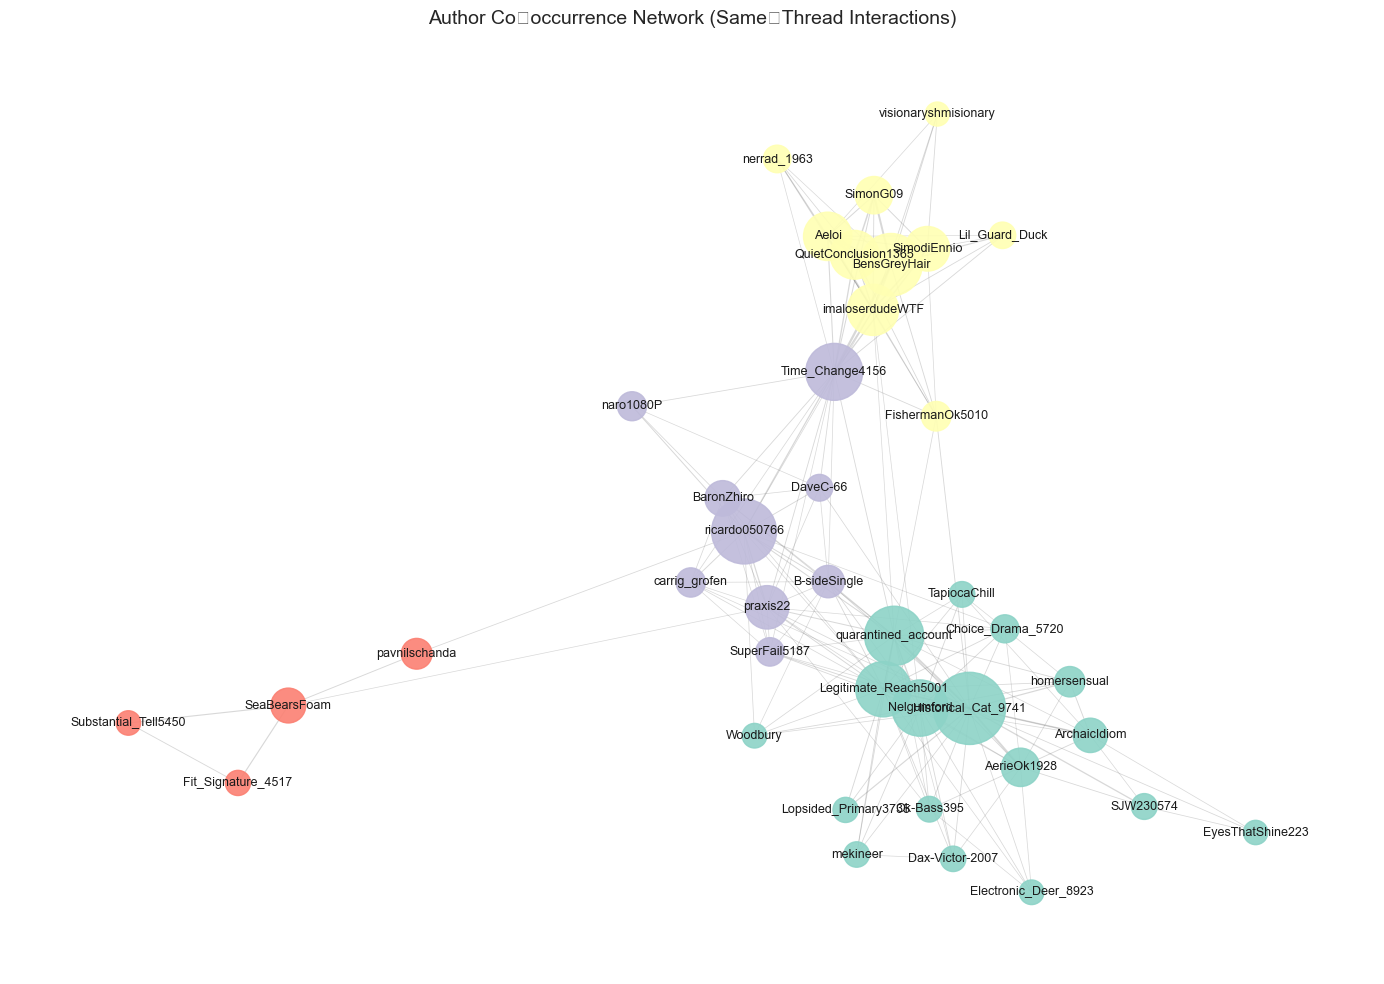

In [28]:
# ---------------------------------------------------------------------------
# Social network analysis: author co-participation network
# ---------------------------------------------------------------------------

import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter
import numpy as np

# Build a thread-level author participation table from the cleaned Reddit corpus.
network_df = reddit_df[['post_id', 'author']].copy()
network_df['author'] = network_df['author'].fillna('unknown').astype(str).str.strip()
network_df = network_df[~network_df['author'].isin(['', '[deleted]', 'AutoModerator', 'unknown'])].copy()

# Each thread contributes a set of unique participants.
thread_participants = network_df.groupby('post_id')['author'].apply(lambda authors: sorted(set(authors)))

# Count how often author pairs appear in the same thread.
edge_counter = Counter()
for authors in thread_participants:
    if len(authors) < 2:
        continue
    for i in range(len(authors)):
        for j in range(i + 1, len(authors)):
            a, b = sorted([authors[i], authors[j]])
            edge_counter[(a, b)] += 1

# Keep only stronger recurring author links.
G = nx.Graph()
min_edge_weight = 5
for (a, b), w in edge_counter.items():
    if w >= min_edge_weight:
        G.add_edge(a, b, weight=w)

print(f'Author SNA nodes: {G.number_of_nodes()}, edges: {G.number_of_edges()}')

if G.number_of_nodes() > 0:
    weighted_degree = dict(G.degree(weight='weight'))

    centrality_df = pd.DataFrame({
        'author': list(G.nodes()),
        'weighted_degree': [weighted_degree[n] for n in G.nodes()],
    }).sort_values('weighted_degree', ascending=False)

    display(centrality_df.head(20))

    # Limit the chart to the most connected authors for readability.
    top_n = 40
    nodes_keep = centrality_df.head(top_n)['author'].tolist()
    subgraph = G.subgraph(nodes_keep).copy()

    if nx.number_connected_components(subgraph) > 1:
        largest_cc = max(nx.connected_components(subgraph), key=len)
        subgraph = subgraph.subgraph(largest_cc).copy()

    if subgraph.number_of_nodes() == 0:
        print("Graph empty after filtering")
    else:
        communities = list(nx.community.greedy_modularity_communities(subgraph))

        color_map = {}
        palette = plt.cm.Set3.colors
        for i, com in enumerate(communities):
            for node in com:
                color_map[node] = palette[i % len(palette)]

        node_colors = [color_map.get(n, "#cccccc") for n in subgraph.nodes()]

        pos = nx.spring_layout(
            subgraph,
            k=3.5,
            iterations=200,
            seed=42
        )

        degrees = np.array([weighted_degree[n] for n in subgraph.nodes()])
        node_sizes = 300 + (degrees - degrees.min()) / (degrees.max() - degrees.min() + 1e-6) * 2400

        weights = np.array([subgraph[u][v]['weight'] for u, v in subgraph.edges()])
        edge_widths = 0.5 + (weights - weights.min()) / (weights.max() - weights.min() + 1e-6) * 2

        plt.figure(figsize=(14, 10))

        nx.draw_networkx_nodes(
            subgraph,
            pos,
            node_size=node_sizes,
            node_color=node_colors,
            alpha=0.9
        )

        nx.draw_networkx_edges(
            subgraph,
            pos,
            width=edge_widths,
            edge_color='gray',
            alpha=0.3
        )

        label_authors = centrality_df.head(50)['author'].tolist()
        nx.draw_networkx_labels(
            subgraph,
            pos,
            labels={n: n for n in label_authors if n in subgraph.nodes()},
            font_size=9
        )

        plt.title("Author Co-occurrence Network (Same-Thread Interactions)", fontsize=14)
        plt.axis('off')
        plt.tight_layout()
        plt.show()
else:
    print("Graph empty. Lower min_edge_weight.")

### Step 21 - Build The Term Co-Occurrence Network

This cell complements the author network with a lexical network built from the most frequent tokens in the cleaned corpus.

SNA nodes: 60, edges: 1813


,term,weighted_degree
33,love,13767
47,human,12916
7,experience,7947
25,help,7245
48,emotional,7117
49,voice,5650
43,understand,5311
15,personality,4544
8,characters,4406
18,story,4345


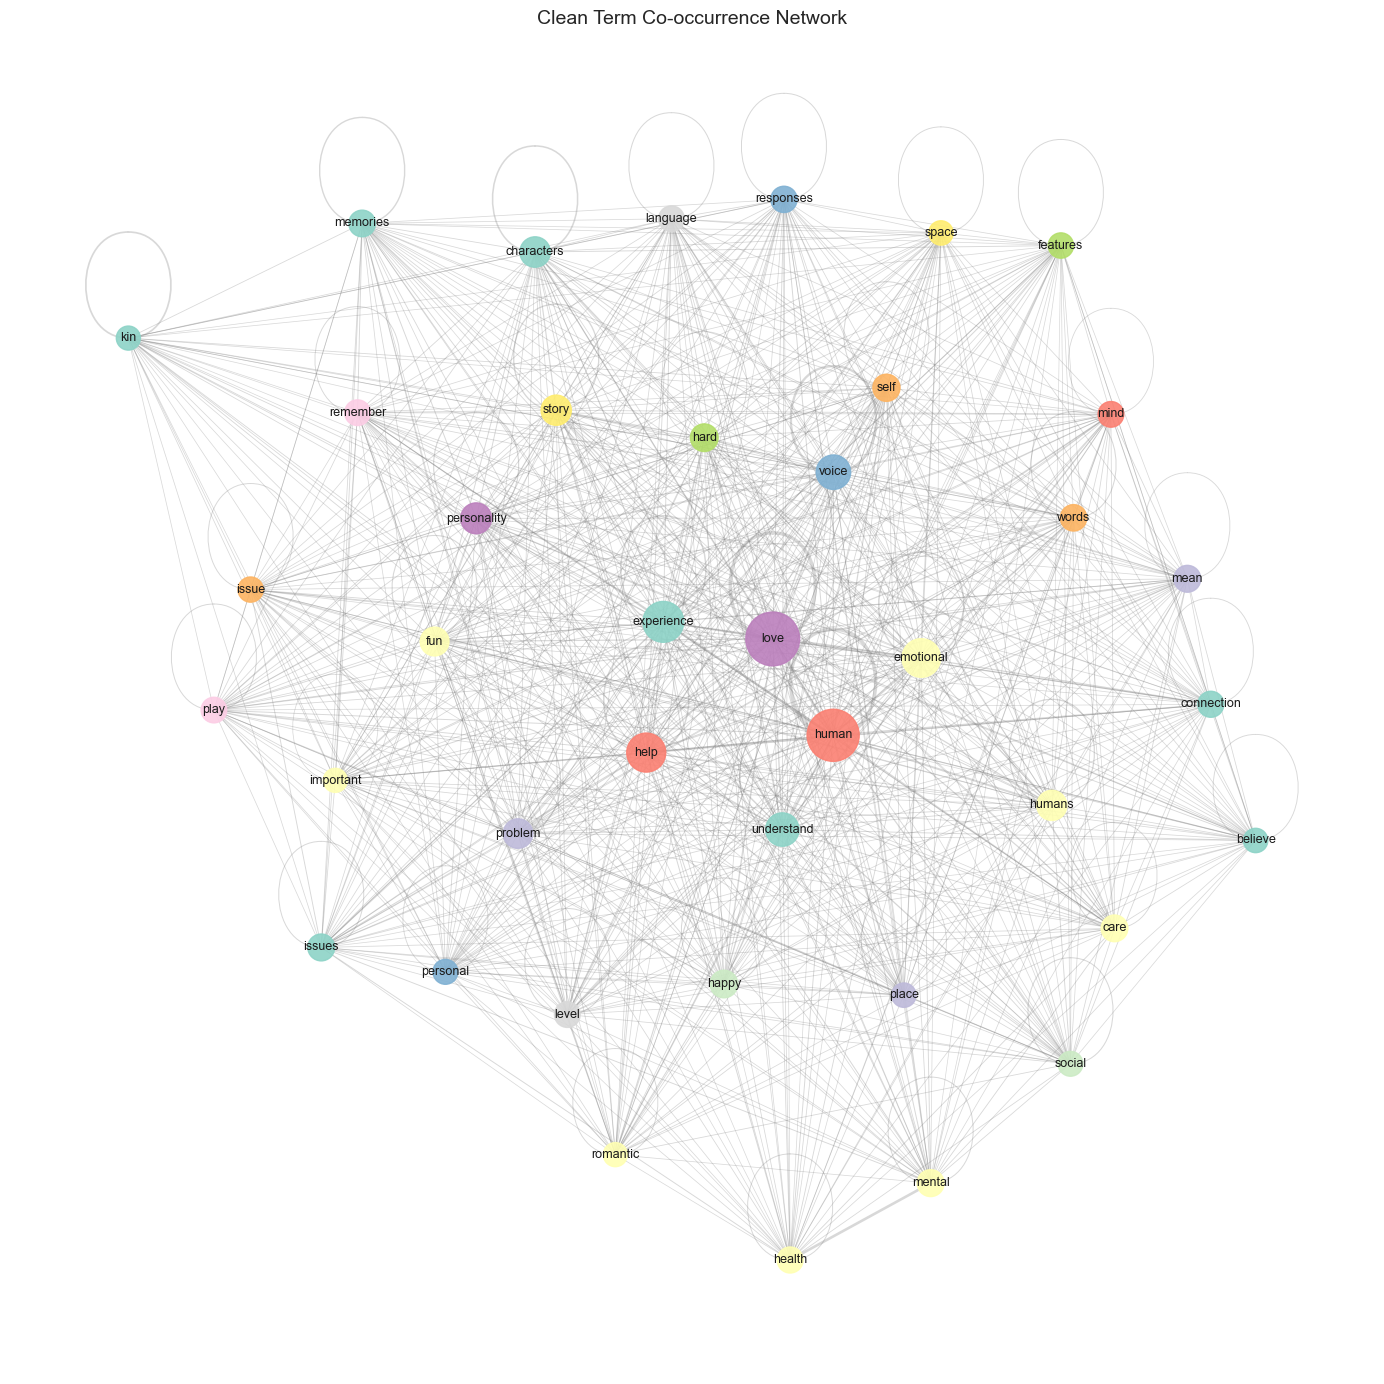

In [29]:
# ---------------------------------------------------------------------------
# Social network analysis: term co-occurrence network
# ---------------------------------------------------------------------------

import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter
import numpy as np

# Keep only the highest-frequency terms for a readable co-occurrence graph.
network_vocab = set(term_freq_df.head(60)['term'].tolist())

# Count term co-occurrence inside a short sliding window.
edge_counter = Counter()
window_size = 4

for txt in analysis_text_series:
    doc_terms = [t for t in tokenize_for_analysis(txt) if t in network_vocab]
    for i in range(len(doc_terms)):
        for j in range(i + 1, min(i + window_size, len(doc_terms))):
            a, b = sorted([doc_terms[i], doc_terms[j]])
            edge_counter[(a, b)] += 1

# Build a filtered graph using only stronger recurring term links.
G = nx.Graph()
min_edge_weight = 10
for (a, b), w in edge_counter.items():
    if w >= min_edge_weight:
        G.add_edge(a, b, weight=w)

print(f'SNA nodes: {G.number_of_nodes()}, edges: {G.number_of_edges()}')

if G.number_of_nodes() > 0:
    weighted_degree = dict(G.degree(weight='weight'))

    centrality_df = pd.DataFrame({
        'term': list(G.nodes()),
        'weighted_degree': [weighted_degree[n] for n in G.nodes()],
    }).sort_values('weighted_degree', ascending=False)

    display(centrality_df.head(20))
    centrality_df.to_csv(REDDIT_SNA_CENTRALITY_CSV, index=False, encoding='utf-8-sig')
    print(f'Saved network centrality metrics to {REDDIT_SNA_CENTRALITY_CSV}')

    # Keep only the most connected terms for the final chart.
    top_n = 40
    nodes_keep = centrality_df.head(top_n)['term'].tolist()
    subgraph = G.subgraph(nodes_keep).copy()

    if nx.number_connected_components(subgraph) > 1:
        largest_cc = max(nx.connected_components(subgraph), key=len)
        subgraph = subgraph.subgraph(largest_cc).copy()

    if subgraph.number_of_nodes() == 0:
        print("Graph empty after filtering")
    else:
        communities = list(nx.community.greedy_modularity_communities(subgraph))

        color_map = {}
        palette = plt.cm.Set3.colors
        for i, com in enumerate(communities):
            for node in com:
                color_map[node] = palette[i % len(palette)]

        node_colors = [color_map.get(n, "#cccccc") for n in subgraph.nodes()]

        pos = nx.spring_layout(
            subgraph,
            k=3.5,
            iterations=200,
            seed=42
        )

        degrees = np.array([weighted_degree[n] for n in subgraph.nodes()])
        node_sizes = 300 + (degrees - degrees.min()) / (degrees.max() - degrees.min() + 1e-6) * 1200

        weights = np.array([subgraph[u][v]['weight'] for u, v in subgraph.edges()])
        edge_widths = 0.5 + (weights - weights.min()) / (weights.max() - weights.min() + 1e-6) * 2

        plt.figure(figsize=(14, 14))

        nx.draw_networkx_nodes(
            subgraph,
            pos,
            node_size=node_sizes,
            node_color=node_colors,
            alpha=0.9
        )

        nx.draw_networkx_edges(
            subgraph,
            pos,
            width=edge_widths,
            edge_color='gray',
            alpha=0.3
        )

        label_nodes = centrality_df.head(50)['term'].tolist()
        nx.draw_networkx_labels(
            subgraph,
            pos,
            labels={n: n for n in label_nodes if n in subgraph.nodes()},
            font_size=9
        )

        plt.title("Clean Term Co-occurrence Network", fontsize=14)
        plt.axis('off')
        plt.tight_layout()
        plt.show()
else:
    print("Graph empty. Lower thresholds.")

## Final Export And Topic Reporting

This section saves the main cleaned dataset, then builds the topic-level reporting assets used for interpretation, appendix tables, and downstream analysis.

### Step 22 - Save The Final Cleaned Reddit Dataset

This cell writes the final combined Reddit analysis table to disk. Treat this output as the main reusable dataset for downstream reporting and additional modeling.

In [30]:
# Save the final cleaned Reddit analysis dataset for downstream reuse.
reddit_df.to_csv(OUTPUT_PATH, index=False)
print(f'Saved final Reddit sentiment dataset to {OUTPUT_PATH.resolve()}')

Saved final Reddit sentiment dataset to D:\ANALYTICS\REDDITCRAWL\combined_ai_companion_reddit_sentiment_analysis_final.csv


### Step 23 - Define The Topic Example Extraction Helper

This helper turns the LDA model output into human-readable topic labels, topic assignments, and example records for each topic.

In [12]:
def build_topic_example_table_from_existing_model(df, label, best_k_value, lda_model, dtm_matrix, feature_names, score_df, top_n_terms=8, examples_per_topic=3):
    """Assign dominant topics and export representative example rows for each topic."""
    if len(df) != dtm_matrix.shape[0]:
        raise ValueError('Row count mismatch: df and dtm_matrix must describe the same documents in the same order.')

    best_k_value = int(best_k_value)
    topic_probs = lda_model.transform(dtm_matrix)
    dominant_topic = topic_probs.argmax(axis=1)
    dominant_score = topic_probs.max(axis=1)

    assigned_df = df.copy().reset_index(drop=True)
    assigned_df['topic_id'] = dominant_topic + 1
    assigned_df['topic_score'] = dominant_score
    assigned_df['dataset_version'] = label

    topic_label_rows = []
    for topic_idx, topic_weights in enumerate(lda_model.components_):
        top_idx = topic_weights.argsort()[-top_n_terms:][::-1]
        topic_terms = [feature_names[i] for i in top_idx]
        topic_label_rows.append({
            'dataset_version': label,
            'best_k': best_k_value,
            'topic_id': topic_idx + 1,
            'topic_terms': ', '.join(topic_terms),
        })
    topic_labels_df = pd.DataFrame(topic_label_rows)

    assigned_df = assigned_df.merge(topic_labels_df, on='topic_id', how='left')
    assigned_df['content_preview'] = assigned_df['text'].fillna('').astype(str).str.replace(r'\s+', ' ', regex=True).str.slice(0, 650)

    example_rows = []
    for topic_id in sorted(assigned_df['topic_id'].dropna().unique()):
        topic_slice = assigned_df[assigned_df['topic_id'] == topic_id].sort_values('topic_score', ascending=False).head(examples_per_topic)
        for _, row in topic_slice.iterrows():
            example_rows.append({
                'dataset_version': label,
                'best_k': best_k_value,
                'topic_id': int(topic_id),
                'topic_terms': row['topic_terms'],
                'topic_score': float(row['topic_score']),
                'query': row.get('query', ''),
                'title': row.get('title', ''),
                'comment_or_content': row['content_preview'],
                'url': row.get('final_url', row.get('url', '')),
            })

    examples_df = pd.DataFrame(example_rows)
    return best_k_value, score_df.copy(), topic_labels_df, assigned_df, examples_df

### Step 24 - Reload Saved Topic Artifacts After A Kernel Reset

This cell makes the notebook resumable by reloading saved topic-model outputs from disk so you can continue the reporting workflow without retraining the model immediately.

In [14]:
# Reload saved Reddit LDA artifacts so the topic-reporting section can resume after a kernel reset
NOTEBOOK_DIR = Path.cwd()
lda_scores_path = NOTEBOOK_DIR / REDDIT_LDA_MODEL_SCORES_CSV
lda_topic_terms_path = NOTEBOOK_DIR / REDDIT_LDA_TOPIC_TERMS_CSV
strict_topic_output_dir = NOTEBOOK_DIR / 'topic_category_exports'
strict_topic_export_summary_path = strict_topic_output_dir / 'topic_category_summary.csv'
strict_topic_examples_path = NOTEBOOK_DIR / 'topic_example_articles.csv'
reddit_topic_sentiment_path = NOTEBOOK_DIR / 'topic_sentiment_summary.csv'

model_scores_df = pd.read_csv(lda_scores_path)
if 'combined_rank' in model_scores_df.columns:
    best_k = int(model_scores_df.sort_values('combined_rank').iloc[0]['k'])
else:
    best_k = int(model_scores_df.iloc[0]['k'])

lda_topic_terms_df = pd.read_csv(lda_topic_terms_path) if lda_topic_terms_path.exists() else pd.DataFrame()
strict_topic_export_summary = pd.read_csv(strict_topic_export_summary_path) if strict_topic_export_summary_path.exists() else pd.DataFrame()
strict_best_k = int(strict_topic_export_summary['best_k'].iloc[0]) if not strict_topic_export_summary.empty and 'best_k' in strict_topic_export_summary.columns else best_k

strict_topic_csv_paths = []
if not strict_topic_export_summary.empty and 'output_csv' in strict_topic_export_summary.columns:
    strict_topic_csv_paths = [Path(p) for p in strict_topic_export_summary['output_csv'].dropna().tolist()]

strict_topic_frames = [pd.read_csv(path) for path in strict_topic_csv_paths if path.exists()]
strict_topic_assignments = pd.concat(strict_topic_frames, ignore_index=True) if strict_topic_frames else pd.DataFrame()

if not strict_topic_assignments.empty and {'topic_id', 'topic_terms'}.issubset(strict_topic_assignments.columns):
    strict_topic_labels = (
        strict_topic_assignments[['topic_id', 'topic_terms']]
        .drop_duplicates()
        .sort_values('topic_id')
        .assign(dataset_version='strict', best_k=strict_best_k)
        [['dataset_version', 'best_k', 'topic_id', 'topic_terms']]
        .reset_index(drop=True)
    )
else:
    strict_topic_labels = pd.DataFrame(columns=['dataset_version', 'best_k', 'topic_id', 'topic_terms'])

strict_topic_examples = pd.read_csv(strict_topic_examples_path) if strict_topic_examples_path.exists() else pd.DataFrame()
reddit_topic_sentiment_summary = pd.read_csv(reddit_topic_sentiment_path) if reddit_topic_sentiment_path.exists() else pd.DataFrame()
strict_lda_scores = model_scores_df.copy()

print(f'Loaded best_k={best_k} from {lda_scores_path}')
print(f'Loaded LDA topic terms rows: {len(lda_topic_terms_df)}')
print(f'Loaded strict topic summary rows: {len(strict_topic_export_summary)}')
print(f'Loaded strict topic assignments rows: {len(strict_topic_assignments)}')
print(f'Loaded strict topic examples rows: {len(strict_topic_examples)}')
print(f'Loaded Reddit topic sentiment rows: {len(reddit_topic_sentiment_summary)}')
if 'models_by_k' not in globals() or best_k not in models_by_k:
    print('Note: CSV reload restores tables, but not the in-memory LDA model object. Re-run the earlier LDA model cells if you need to recompute topic assignments from scratch.')

Loaded best_k=5 from d:\ANALYTICS\REDDITCRAWL\ai_companion_reddit_lda_k4_k8_scores.csv
Loaded LDA topic terms rows: 360
Loaded strict topic summary rows: 5
Loaded strict topic assignments rows: 32459
Loaded strict topic examples rows: 15
Loaded Reddit topic sentiment rows: 0
Note: CSV reload restores tables, but not the in-memory LDA model object. Re-run the earlier LDA model cells if you need to recompute topic assignments from scratch.


### Step 25 - Export Representative Example Records For Each Topic

This cell assigns each Reddit record to its dominant topic and exports example rows that help interpret what each topic actually contains.

In [4]:
# Build topic example rows from the selected best-K LDA model
strict_best_k, strict_lda_scores, strict_topic_labels, strict_topic_assignments, strict_topic_examples = build_topic_example_table_from_existing_model(
    sentiment_df,
    label='strict',
    best_k_value=best_k,
    lda_model=models_by_k[best_k],
    dtm_matrix=dtm,
    feature_names=feature_names,
    score_df=model_scores_df,
    examples_per_topic=3,
)

strict_topic_examples_path = 'topic_example_articles.csv'
strict_topic_examples.to_csv(strict_topic_examples_path, index=False, encoding='utf-8-sig')

print(f'Strict best K (reused from main LDA): {strict_best_k}')
print(f'Saved strict topic examples to {strict_topic_examples_path}')
display(strict_topic_labels)
strict_topic_examples[['topic_id', 'topic_terms', 'query', 'title', 'topic_score', 'comment_or_content']]

NameError: name 'build_topic_example_table_from_existing_model' is not defined

### Step 26 - Export One CSV Per Topic

This step creates one topic-specific CSV file per dominant topic and records all exported files in a summary index.

In [16]:
# Export one Reddit CSV per dominant topic category
NOTEBOOK_DIR = Path.cwd()
strict_topic_output_dir = NOTEBOOK_DIR / 'topic_category_exports'
strict_topic_output_dir.mkdir(parents=True, exist_ok=True)

def slugify_topic_label(text: str) -> str:
    text = re.sub(r'[^a-z0-9]+', '_', str(text).lower())
    return text.strip('_')[:80]

strict_topic_export_rows = []

for topic_id in sorted(strict_topic_assignments['topic_id'].dropna().unique()):
    topic_id = int(topic_id)
    topic_slice = strict_topic_assignments[strict_topic_assignments['topic_id'] == topic_id].copy()

    if topic_slice.empty:
        continue

    topic_terms_series = topic_slice['topic_terms'].dropna() if 'topic_terms' in topic_slice.columns else pd.Series(dtype='object')
    topic_terms = topic_terms_series.iloc[0] if not topic_terms_series.empty else f'topic_{topic_id}'
    topic_slug = slugify_topic_label(topic_terms) or f'topic_{topic_id}'
    output_path = strict_topic_output_dir / f'strict_topic_{topic_id}_{topic_slug}.csv'

    topic_slice.to_csv(output_path, index=False, encoding='utf-8-sig')

    strict_topic_export_rows.append({
        'best_k': strict_best_k,
        'topic_id': topic_id,
        'topic_terms': topic_terms,
        'article_count': len(topic_slice),
        'output_csv': str(output_path),
    })

strict_topic_export_summary = pd.DataFrame(strict_topic_export_rows).sort_values('topic_id').reset_index(drop=True)
strict_topic_export_summary_path = strict_topic_output_dir / 'topic_category_summary.csv'
strict_topic_export_summary.to_csv(strict_topic_export_summary_path, index=False, encoding='utf-8-sig')

print(f'Strict best K used for category export: {strict_best_k}')
print(f'Saved topic-separated CSV files to: {strict_topic_output_dir}')
print(f'Saved export summary to: {strict_topic_export_summary_path}')
strict_topic_export_summary

Strict best K used for category export: 5
Saved topic-separated CSV files to: d:\ANALYTICS\REDDITCRAWL\topic_category_exports
Saved export summary to: d:\ANALYTICS\REDDITCRAWL\topic_category_exports\topic_category_summary.csv


,best_k,topic_id,topic_terms,article_count,output_csv
0,5,1,"emotional, human, mental, health, self, mental...",4353,d:\ANALYTICS\REDDITCRAWL\topic_category_export...
1,5,2,"love, story, fun, words, play, role, happy, night",6138,d:\ANALYTICS\REDDITCRAWL\topic_category_export...
2,5,3,"subscription, sm, money, pay, haven, dots, iss...",9070,d:\ANALYTICS\REDDITCRAWL\topic_category_export...
3,5,4,"voice, characters, experience, personality, ki...",6041,d:\ANALYTICS\REDDITCRAWL\topic_category_export...
4,5,5,"human, love, help, experience, connection, und...",6857,d:\ANALYTICS\REDDITCRAWL\topic_category_export...


### Step 27 - Summarize Sentiment By Topic

This final reporting cell combines topic assignments with sentiment labels so you can see which topics skew more positive, neutral, or negative.

Sentiment label percentage for each topic:


sentiment_label,topic_id,topic_terms,positive,neutral,negative
0,1,"emotional, human, mental, health, self, mental...",65.27,13.94,20.79
1,2,"love, story, fun, words, play, role, happy, night",77.52,10.12,12.37
2,3,"subscription, sm, money, pay, haven, dots, iss...",63.08,10.18,26.75
3,4,"voice, characters, experience, personality, ki...",80.40,9.01,10.59
4,5,"human, love, help, experience, connection, und...",74.36,6.07,19.57


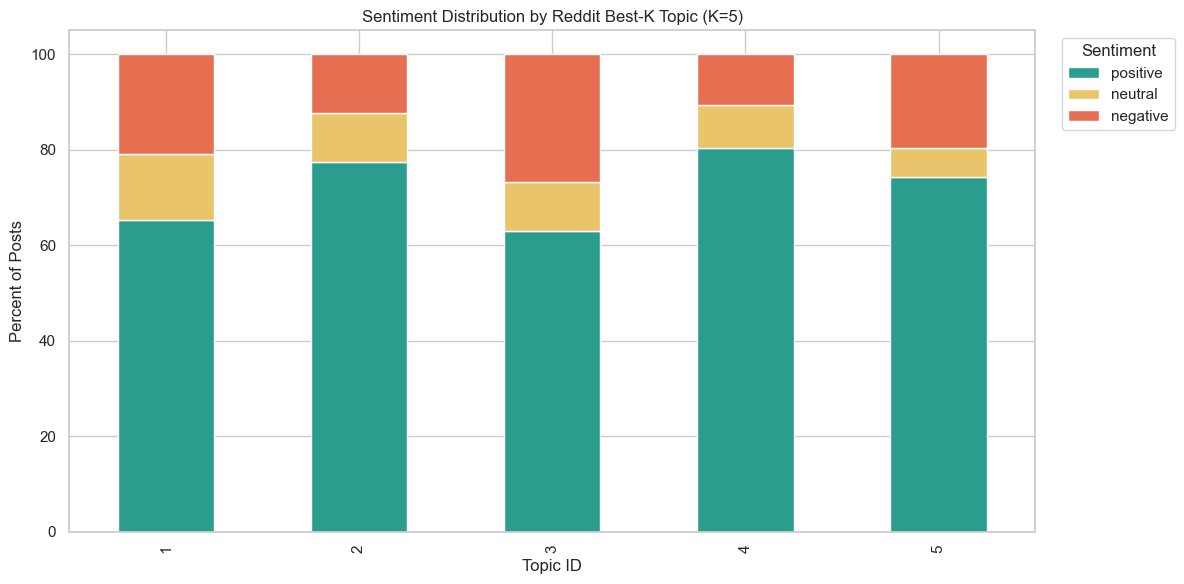

Reddit best K used for topic sentiment analysis: 5
Saved topic sentiment summary to: d:\ANALYTICS\REDDITCRAWL\topic_sentiment_summary.csv


,best_k,topic_id,topic_terms,sentiment_label,article_count,topic_total_articles,sentiment_pct,avg_compound
0,5,1,"emotional, human, mental, health, self, mental...",negative,905,4353,20.79,-0.4429
1,5,1,"emotional, human, mental, health, self, mental...",neutral,607,4353,13.94,-0.0004
2,5,1,"emotional, human, mental, health, self, mental...",positive,2841,4353,65.27,0.5973
3,5,2,"love, story, fun, words, play, role, happy, night",negative,759,6138,12.37,-0.3683
4,5,2,"love, story, fun, words, play, role, happy, night",neutral,621,6138,10.12,0.0007
5,5,2,"love, story, fun, words, play, role, happy, night",positive,4758,6138,77.52,0.6737
6,5,3,"subscription, sm, money, pay, haven, dots, iss...",negative,2426,9070,26.75,-0.4417
7,5,3,"subscription, sm, money, pay, haven, dots, iss...",neutral,923,9070,10.18,-0.0001
8,5,3,"subscription, sm, money, pay, haven, dots, iss...",positive,5721,9070,63.08,0.5873
9,5,4,"voice, characters, experience, personality, ki...",negative,640,6041,10.59,-0.3834


In [17]:
# Summarize sentiment by dominant topic using the Reddit best-K topic assignments
reddit_topic_sentiment_path = NOTEBOOK_DIR / 'topic_sentiment_summary.csv'

reddit_topic_sentiment_summary = (
    strict_topic_assignments
    .dropna(subset=['topic_id'])
    .assign(topic_id=lambda df: df['topic_id'].astype(int))
    .groupby(['topic_id', 'topic_terms', 'sentiment_label'], dropna=False)
    .agg(
        article_count=('sentiment_label', 'size'),
        avg_compound=('compound', 'mean'),
    )
    .reset_index()
)

topic_totals = (
    strict_topic_assignments
    .dropna(subset=['topic_id'])
    .assign(topic_id=lambda df: df['topic_id'].astype(int))
    .groupby(['topic_id', 'topic_terms'], dropna=False)
    .size()
    .reset_index(name='topic_total_articles')
)

reddit_topic_sentiment_summary = (
    reddit_topic_sentiment_summary
    .merge(topic_totals, on=['topic_id', 'topic_terms'], how='left')
    .assign(
        best_k=strict_best_k,
        sentiment_pct=lambda df: (df['article_count'] / df['topic_total_articles'] * 100).round(2),
        avg_compound=lambda df: df['avg_compound'].round(4),
    )
    [['best_k', 'topic_id', 'topic_terms', 'sentiment_label', 'article_count', 'topic_total_articles', 'sentiment_pct', 'avg_compound']]
    .sort_values(['topic_id', 'sentiment_label'])
    .reset_index(drop=True)
)

reddit_topic_sentiment_summary.to_csv(reddit_topic_sentiment_path, index=False, encoding='utf-8-sig')

plot_order = ['positive', 'neutral', 'negative']
available_labels = [label for label in plot_order if label in reddit_topic_sentiment_summary['sentiment_label'].dropna().unique()]
plot_df = (
    reddit_topic_sentiment_summary
    .pivot_table(index='topic_id', columns='sentiment_label', values='sentiment_pct', fill_value=0)
    .reindex(columns=available_labels)
)

topic_sentiment_pct_table = (
    reddit_topic_sentiment_summary
    .pivot_table(
        index=['topic_id', 'topic_terms'],
        columns='sentiment_label',
        values='sentiment_pct',
        fill_value=0,
    )
    .reindex(columns=plot_order, fill_value=0)
    .reset_index()
)

print('Sentiment label percentage for each topic:')
display(topic_sentiment_pct_table)

if not plot_df.empty:
    ax = plot_df.plot(kind='bar', stacked=True, figsize=(12, 6), color=['#2A9D8F', '#E9C46A', '#E76F51'][:len(plot_df.columns)])
    ax.set_title(f'Sentiment Distribution by Reddit Best-K Topic (K={strict_best_k})')
    ax.set_xlabel('Topic ID')
    ax.set_ylabel('Percent of Records')
    ax.legend(title='Sentiment', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

print(f'Reddit best K used for topic sentiment analysis: {strict_best_k}')
print(f'Saved topic sentiment summary to: {reddit_topic_sentiment_path}')
reddit_topic_sentiment_summary